In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
!pip install openpyxl xlrd -q

In [51]:
from pathlib import Path
import re
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
ROSTAT_DIR = Path("/content/drive/MyDrive/rostat")

OLD_FILE = ROSTAT_DIR / "[2016-2020]_price_spred.xlsx"
NEW_FILE = ROSTAT_DIR / "[2022-2026]_price_spred.xlsx"

OUT_DIR = ROSTAT_DIR / "processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_LONG = OUT_DIR / "weekly_prices_long.csv"
OUT_WIDE = OUT_DIR / "weekly_prices_wide.csv"
OUT_PRODUCTS = OUT_DIR / "product_dictionary.csv"
OUT_GROUPS = OUT_DIR / "product_groups.csv"
OUT_DUPLICATES = OUT_DIR / "duplicates_report.csv"

print("Старый файл:", OLD_FILE, OLD_FILE.exists())
print("Новый файл:", NEW_FILE, NEW_FILE.exists())

if not OLD_FILE.exists():
    raise FileNotFoundError(f"Не найден файл: {OLD_FILE}")

if not NEW_FILE.exists():
    raise FileNotFoundError(f"Не найден файл: {NEW_FILE}")

Старый файл: /content/drive/MyDrive/rostat/[2016-2020]_price_spred.xlsx True
Новый файл: /content/drive/MyDrive/rostat/[2022-2026]_price_spred.xlsx True


In [52]:
TMP_DIR = Path("/tmp/rostat_excel_tmp")
TMP_DIR.mkdir(parents=True, exist_ok=True)


def get_real_excel_path_and_engine(file_path):
    """
    Определяет реальный формат Excel-файла по первым байтам.

    Если файл называется .xls, но внутри является .xlsx,
    создаётся временная копия с расширением .xlsx,
    чтобы openpyxl смог её прочитать.
    """

    file_path = Path(file_path)

    with open(file_path, "rb") as f:
        signature = f.read(8)

    # Настоящий xlsx — это zip, начинается с PK
    if signature.startswith(b"PK"):
        tmp_path = TMP_DIR / (file_path.stem + "_fixed.xlsx")
        shutil.copy(file_path, tmp_path)
        return tmp_path, "openpyxl"

    # Настоящий старый xls
    if signature.startswith(b"\xD0\xCF\x11\xE0"):
        return file_path, "xlrd"

    raise ValueError(
        f"Не удалось определить формат файла {file_path.name}. "
        f"Первые байты: {signature}"
    )


def read_excel_any(file_path, sheet_name, header=None):
    real_path, engine = get_real_excel_path_and_engine(file_path)

    return pd.read_excel(
        real_path,
        sheet_name=sheet_name,
        header=header,
        engine=engine
    )


def excel_file_any(file_path):
    real_path, engine = get_real_excel_path_and_engine(file_path)

    return pd.ExcelFile(
        real_path,
        engine=engine
    )


for path in [OLD_FILE, NEW_FILE]:
    real_path, engine = get_real_excel_path_and_engine(path)
    print(path.name, "->", engine, "| читается как:", real_path.name)

[2016-2020]_price_spred.xlsx -> openpyxl | читается как: [2016-2020]_price_spred_fixed.xlsx
[2022-2026]_price_spred.xlsx -> openpyxl | читается как: [2022-2026]_price_spred_fixed.xlsx


In [53]:
MONTH_MAP = {
    "января": 1,
    "февраля": 2,
    "марта": 3,
    "апреля": 4,
    "мая": 5,
    "июня": 6,
    "июля": 7,
    "августа": 8,
    "сентября": 9,
    "октября": 10,
    "ноября": 11,
    "декабря": 12,
}


def clean_text(value):
    if pd.isna(value):
        return None

    text = str(value).strip()
    text = text.replace("\n", " ")
    text = text.replace("\xa0", " ")
    text = re.sub(r"\s+", " ", text)

    if text == "":
        return None

    return text


def clean_price(value):
    if pd.isna(value):
        return np.nan

    if isinstance(value, str):
        value = value.replace("\xa0", "")
        value = value.replace(" ", "")
        value = value.replace(",", ".")
        value = value.replace("−", "-")

    return pd.to_numeric(value, errors="coerce")


def parse_russian_date(value, default_year=None):
    if pd.isna(value):
        return pd.NaT

    if isinstance(value, pd.Timestamp):
        return value.normalize()

    text = clean_text(value)

    if text is None:
        return pd.NaT

    text = text.lower()

    match = re.search(r"(\d{1,2})[.\-/](\d{1,2})[.\-/](\d{4})", text)
    if match:
        return pd.Timestamp(
            year=int(match.group(3)),
            month=int(match.group(2)),
            day=int(match.group(1))
        )

    match = re.search(r"на\s+(\d{1,2})\s+([а-яё]+)\s+(\d{4})", text)
    if match:
        day = int(match.group(1))
        month = MONTH_MAP.get(match.group(2))
        year = int(match.group(3))

        if month:
            return pd.Timestamp(year=year, month=month, day=day)

    match = re.search(r"на\s+(\d{1,2})\s+([а-яё]+)", text)
    if match and default_year is not None:
        day = int(match.group(1))
        month = MONTH_MAP.get(match.group(2))

        if month:
            return pd.Timestamp(year=int(default_year), month=month, day=day)

    match = re.search(r"(\d{1,2})\s+([а-яё]+)\s+(\d{4})", text)
    if match:
        day = int(match.group(1))
        month = MONTH_MAP.get(match.group(2))
        year = int(match.group(3))

        if month:
            return pd.Timestamp(year=year, month=month, day=day)

    return pd.NaT


def split_product_and_unit(product_raw):
    product_raw = clean_text(product_raw)

    if product_raw is None:
        return None, None

    if "," not in product_raw:
        return product_raw, None

    product_name, unit = product_raw.rsplit(",", 1)

    return product_name.strip(), unit.strip()


def normalize_product_key(product_name, unit):
    product_name = clean_text(product_name)
    unit = clean_text(unit)

    if product_name is None:
        return None

    key = product_name.lower()
    key = key.replace("ё", "е")
    key = re.sub(r"[^а-яa-z0-9]+", "_", key)
    key = re.sub(r"_+", "_", key).strip("_")

    if unit:
        unit_key = unit.lower()
        unit_key = unit_key.replace("ё", "е")
        unit_key = re.sub(r"[^а-яa-z0-9]+", "_", unit_key)
        unit_key = re.sub(r"_+", "_", unit_key).strip("_")
        key = f"{key}__{unit_key}"

    return key

In [54]:
def process_old_2016_2020_file(file_path):
    raw = read_excel_any(
        file_path,
        sheet_name="Данные",
        header=None
    )

    print("Структура старого файла:")
    print("Размер листа Данные:", raw.shape)
    display(raw.head(6))

    date_row_idx = 3
    product_col = 0
    region_col = 1

    date_cols = []

    for col_idx, value in raw.iloc[date_row_idx].items():
        parsed_date = parse_russian_date(value)

        if pd.notna(parsed_date):
            date_cols.append((col_idx, parsed_date))

    if len(date_cols) == 0:
        raise ValueError("В старом файле не найдены даты в строке 3")

    data = raw.iloc[date_row_idx + 1:].copy()

    records = []

    for _, row in data.iterrows():
        product_raw = clean_text(row.get(product_col))
        region = clean_text(row.get(region_col))

        if product_raw is None:
            continue

        if region != "Российская Федерация":
            continue

        product_name, unit = split_product_and_unit(product_raw)
        product_key = normalize_product_key(product_name, unit)

        for col_idx, date in date_cols:
            price = clean_price(row.get(col_idx))

            if pd.notna(price):
                records.append({
                    "date": pd.Timestamp(date).normalize(),
                    "year": pd.Timestamp(date).year,
                    "product_raw": product_raw,
                    "product_name": product_name,
                    "unit": unit,
                    "product_key": product_key,
                    "price": float(price),
                    "source_file": Path(file_path).name,
                    "source_sheet": "Данные",
                    "source_priority": 1,
                })

    result = pd.DataFrame(records)

    result = result.sort_values(
        ["date", "product_key"]
    ).reset_index(drop=True)

    print("\nСтарый файл 2016–2020 обработан:")
    print("Строк:", len(result))
    print("Товаров:", result["product_key"].nunique())
    print("Дат:", result["date"].nunique())
    print("Период:", result["date"].min(), "—", result["date"].max())

    display(
        result
        .groupby("year")
        .agg(
            rows=("price", "size"),
            dates=("date", "nunique"),
            products=("product_key", "nunique")
        )
        .reset_index()
    )

    return result

In [55]:
def process_new_2022_2026_file(file_path):
    xls = excel_file_any(file_path)

    print("\nЛисты нового файла:")
    print(xls.sheet_names)

    all_parts = []

    for sheet_name in xls.sheet_names:
        if not re.fullmatch(r"\d{4}", str(sheet_name)):
            continue

        year = int(sheet_name)

        raw = read_excel_any(
            file_path,
            sheet_name=sheet_name,
            header=None
        )

        header_row_idx = None

        for i in range(min(20, len(raw))):
            row_values = raw.iloc[i].astype(str).str.lower().tolist()

            if any("наименование" in value for value in row_values):
                header_row_idx = i
                break

        if header_row_idx is None:
            print(f"Лист {sheet_name} пропущен: не найдена строка 'Наименование'")
            continue

        header = raw.iloc[header_row_idx]

        name_col = None

        for col_idx, value in header.items():
            text = clean_text(value)

            if text and "наименование" in text.lower():
                name_col = col_idx
                break

        date_cols = []

        for col_idx, value in header.items():
            parsed_date = parse_russian_date(value, default_year=year)

            if pd.notna(parsed_date):
                date_cols.append((col_idx, parsed_date))

        if name_col is None or len(date_cols) == 0:
            print(f"Лист {sheet_name} пропущен: не найдены товары или даты")
            continue

        data = raw.iloc[header_row_idx + 1:].copy()

        records = []

        for _, row in data.iterrows():
            product_raw = clean_text(row.get(name_col))

            if product_raw is None:
                continue

            if product_raw.lower().startswith("к содержанию"):
                continue

            product_name, unit = split_product_and_unit(product_raw)
            product_key = normalize_product_key(product_name, unit)

            for col_idx, date in date_cols:
                price = clean_price(row.get(col_idx))

                if pd.notna(price):
                    records.append({
                        "date": pd.Timestamp(date).normalize(),
                        "year": pd.Timestamp(date).year,
                        "product_raw": product_raw,
                        "product_name": product_name,
                        "unit": unit,
                        "product_key": product_key,
                        "price": float(price),
                        "source_file": Path(file_path).name,
                        "source_sheet": str(sheet_name),
                        "source_priority": 2,
                    })

        sheet_df = pd.DataFrame(records)

        if len(sheet_df) > 0:
            print(
                f"Лист {sheet_name}: "
                f"строк={len(sheet_df)}, "
                f"товаров={sheet_df['product_key'].nunique()}, "
                f"дат={sheet_df['date'].nunique()}, "
                f"период={sheet_df['date'].min()} — {sheet_df['date'].max()}"
            )

            all_parts.append(sheet_df)

    if not all_parts:
        return pd.DataFrame()

    result = pd.concat(all_parts, ignore_index=True)

    result = result.sort_values(
        ["date", "product_key"]
    ).reset_index(drop=True)

    print("\nНовый файл 2022–2026 обработан:")
    print("Строк:", len(result))
    print("Товаров:", result["product_key"].nunique())
    print("Дат:", result["date"].nunique())
    print("Период:", result["date"].min(), "—", result["date"].max())

    display(
        result
        .groupby("year")
        .agg(
            rows=("price", "size"),
            dates=("date", "nunique"),
            products=("product_key", "nunique")
        )
        .reset_index()
    )

    return result

In [56]:
product_groups = pd.DataFrame([
    {"product_group_code": "G01", "product_group_name": "Хлеб, крупы, мука и макаронные изделия"},
    {"product_group_code": "G02", "product_group_name": "Молочная продукция и яйца"},
    {"product_group_code": "G03", "product_group_name": "Мясо, птица, рыба и колбасные изделия"},
    {"product_group_code": "G04", "product_group_name": "Овощи, фрукты и картофель"},
    {"product_group_code": "G05", "product_group_name": "Бакалея, масло, сахар, чай, соль"},
    {"product_group_code": "G06", "product_group_name": "Детские товары и детское питание"},
    {"product_group_code": "G07", "product_group_name": "Товары для дома, гигиены и бытовая химия"},
    {"product_group_code": "G08", "product_group_name": "Медицинские товары и лекарства"},
    {"product_group_code": "G09", "product_group_name": "Одежда, обувь и текстиль"},
    {"product_group_code": "G10", "product_group_name": "Топливо и транспортные товары"},
    {"product_group_code": "G11", "product_group_name": "Услуги"},
    {"product_group_code": "G99", "product_group_name": "Прочее"},
])


def assign_product_group(product_name):
    text = clean_text(product_name)

    if text is None:
        return "G99"

    text = text.lower().replace("ё", "е")

    if re.search(r"хлеб|булоч|батон|круп|рис|греч|пшен|пшено|овсян|перлов|манн|макарон|вермиш|мука|печень|сухар|баранк", text):
        return "G01"

    if re.search(r"молок|кефир|сметан|творог|сыр|йогурт|ряжен|сливк|масло слив|яйц", text):
        return "G02"

    if re.search(r"говядин|свинин|баранин|кур|цыплят|птиц|мяс|фарш|рыб|сельд|колбас|сосиск|сардель|ветчин|консерв.*мяс|консерв.*рыб", text):
        return "G03"

    if re.search(r"картоф|капуст|морков|лук|свекл|огурц|помид|томат|яблок|банан|апельс|лимон|виноград|овощ|фрукт|чеснок|груш", text):
        return "G04"

    if re.search(r"сахар|масло подсол|масло раст|чай|соль|кофе|какао|конфет|карамел|шоколад|маргарин|майонез|кетчуп|сок|вода|напит", text):
        return "G05"

    if re.search(r"детск|пелен|подгуз|смес|питание для детей|каша.*дет", text):
        return "G06"

    if re.search(r"мыло|порош|моющ|чистящ|шампун|паста зуб|щетка зуб|бумага туал|салфет|гигиен|дезодорант|стираль|белье|посуда|сковород|кастрюл", text):
        return "G07"

    if re.search(r"лекар|медикамент|бинт|вата|маск|антисепт|термометр|медицин", text):
        return "G08"

    if re.search(r"одежд|обув|куртк|пальто|брюк|сорочк|плать|носк|чулк|белье|трикотаж|ткан|полотен", text):
        return "G09"

    if re.search(r"бензин|дизель|топлив|газомотор|автомоб|шина|масло мотор", text):
        return "G10"

    if re.search(r"услуг|проезд|билет|тариф|жкх|коммун|связ|интернет|парикмах|ремонт|аренд|плата|гостиниц", text):
        return "G11"

    return "G99"

In [57]:
old_prices = process_old_2016_2020_file(OLD_FILE)
new_prices = process_new_2022_2026_file(NEW_FILE)

prices_raw = pd.concat(
    [old_prices, new_prices],
    ignore_index=True
)

prices_raw["date"] = pd.to_datetime(prices_raw["date"])

prices_raw = prices_raw.sort_values(
    ["date", "product_key", "source_priority"]
).reset_index(drop=True)

print("\nИтого до удаления дублей:")
print("Строк:", len(prices_raw))
print("Товаров:", prices_raw["product_key"].nunique())
print("Дат:", prices_raw["date"].nunique())
print("Период:", prices_raw["date"].min(), "—", prices_raw["date"].max())

display(
    prices_raw
    .assign(year=prices_raw["date"].dt.year)
    .groupby("year")
    .agg(
        rows=("price", "size"),
        dates=("date", "nunique"),
        products=("product_key", "nunique")
    )
    .reset_index()
)

Структура старого файла:
Размер листа Данные: (142, 255)


,0,1,2,3,4,5,6,7,8,9,...,245,246,247,248,249,250,251,252,253,254
0,Еженедельные средние потребительские цены (тар...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,23 неделя (на 13 июня 2016 года),24 неделя (на 20 июня 2016 года),1 неделя (на 11 января 2016 года),10 неделя (на 14 марта 2016 года),11 неделя (на 21 марта 2016 года),12 неделя (на 28 марта 2016 года),13 неделя (на 4 апреля 2016 года),14 неделя (на 11 апреля 2016 года),...,43 неделя (на 26 октября 2020 года),44 неделя (на 2 ноября 2020 года),45 неделя (на 9 ноября 2020 года),46 неделя (на 16 ноября 2020 года),47 неделя (на 23 ноября 2020 года),48 неделя (на 30 ноября 2020 года),49 неделя (на 7 декабря 2020 года),5 неделя (на 3 февраля 2020 года),50 неделя (на 14 декабря 2020 года),51 неделя (на 21 декабря 2020 года)
4,"Говядина (кроме бескостного мяса), кг",Российская Федерация,311.8,311.62,313.02,311.48,311.71,311.76,311.53,311.38,...,356.97,357.5,357.46,357.61,358.34,358.81,358.91,344.51,359.13,360.2
5,"Свинина (кроме бескостного мяса), кг",Российская Федерация,256.45,256.75,269.73,260.99,260.11,259.02,257.34,256.28,...,268.98,268.22,267.71,266.98,267.19,267.51,268.09,258.29,268.6,268.13



Старый файл 2016–2020 обработан:
Строк: 18500
Товаров: 110
Дат: 251
Период: 2016-01-11 00:00:00 — 2020-12-21 00:00:00


,year,rows,dates,products
0,2016,3468,51,68
1,2017,3536,51,68
2,2018,3400,50,68
3,2019,3534,52,68
4,2020,4562,47,107



Листы нового файла:
['Содержание', '2022', '2023', '2024', '2025', '2026']
Лист 2022: строк=5457, товаров=108, дат=51, период=2022-01-10 00:00:00 — 2022-12-26 00:00:00
Лист 2023: строк=5610, товаров=110, дат=51, период=2023-01-09 00:00:00 — 2023-12-25 00:00:00
Лист 2024: строк=5606, товаров=110, дат=51, период=2024-01-09 00:00:00 — 2024-12-23 00:00:00
Лист 2025: строк=5610, товаров=110, дат=51, период=2025-01-09 00:00:00 — 2025-12-22 00:00:00
Лист 2026: строк=1554, товаров=112, дат=14, период=2026-01-12 00:00:00 — 2026-04-13 00:00:00

Новый файл 2022–2026 обработан:
Строк: 23837
Товаров: 131
Дат: 218
Период: 2022-01-10 00:00:00 — 2026-04-13 00:00:00


,year,rows,dates,products
0,2022,5457,51,108
1,2023,5610,51,110
2,2024,5606,51,110
3,2025,5610,51,110
4,2026,1554,14,112



Итого до удаления дублей:
Строк: 42337
Товаров: 159
Дат: 469
Период: 2016-01-11 00:00:00 — 2026-04-13 00:00:00


,year,rows,dates,products
0,2016,3468,51,68
1,2017,3536,51,68
2,2018,3400,50,68
3,2019,3534,52,68
4,2020,4562,47,107
5,2022,5457,51,108
6,2023,5610,51,110
7,2024,5606,51,110
8,2025,5610,51,110
9,2026,1554,14,112


In [58]:
duplicates_report = (
    prices_raw
    .groupby(["date", "product_key"])
    .agg(
        rows_count=("price", "size"),
        min_price=("price", "min"),
        max_price=("price", "max"),
        sources=("source_file", lambda x: ", ".join(sorted(set(x)))),
        sheets=("source_sheet", lambda x: ", ".join(sorted(set(map(str, x)))))
    )
    .reset_index()
)

duplicates_report = duplicates_report[
    duplicates_report["rows_count"] > 1
].copy()

duplicates_report.to_csv(
    OUT_DUPLICATES,
    index=False,
    encoding="utf-8-sig"
)


prices_dedup = (
    prices_raw
    .sort_values(
        ["date", "product_key", "source_priority"],
        ascending=[True, True, True]
    )
    .drop_duplicates(
        subset=["date", "product_key"],
        keep="last"
    )
    .reset_index(drop=True)
)

print("После удаления дублей:")
print("Строк:", len(prices_dedup))
print("Товаров:", prices_dedup["product_key"].nunique())
print("Дат:", prices_dedup["date"].nunique())
print("Период:", prices_dedup["date"].min(), "—", prices_dedup["date"].max())

После удаления дублей:
Строк: 42269
Товаров: 159
Дат: 469
Период: 2016-01-11 00:00:00 — 2026-04-13 00:00:00


In [59]:
products = (
    prices_dedup[["product_key", "product_name", "unit", "product_raw"]]
    .drop_duplicates(subset=["product_key"])
    .sort_values("product_name")
    .reset_index(drop=True)
)

products["product_code"] = [
    f"P{str(i + 1).zfill(4)}"
    for i in range(len(products))
]

products["product_group_code"] = products["product_name"].apply(assign_product_group)

products = products.merge(
    product_groups,
    on="product_group_code",
    how="left"
)

products = products[
    [
        "product_code",
        "product_key",
        "product_name",
        "unit",
        "product_group_code",
        "product_group_name",
        "product_raw"
    ]
]


prices_long = prices_dedup.merge(
    products[["product_code", "product_key"]],
    on="product_key",
    how="left"
)

prices_long = prices_long[
    [
        "date",
        "year",
        "product_code",
        "price",
        "source_file",
        "source_sheet"
    ]
].sort_values(["date", "product_code"]).reset_index(drop=True)


prices_wide = (
    prices_long
    .pivot_table(
        index="date",
        columns="product_code",
        values="price",
        aggfunc="mean"
    )
    .reset_index()
)


prices_long.to_csv(
    OUT_LONG,
    index=False,
    encoding="utf-8-sig"
)

prices_wide.to_csv(
    OUT_WIDE,
    index=False,
    encoding="utf-8-sig"
)

products.to_csv(
    OUT_PRODUCTS,
    index=False,
    encoding="utf-8-sig"
)

product_groups.to_csv(
    OUT_GROUPS,
    index=False,
    encoding="utf-8-sig"
)

print("Файлы сохранены:")
print(OUT_LONG)
print(OUT_WIDE)
print(OUT_PRODUCTS)
print(OUT_GROUPS)
print(OUT_DUPLICATES)

Файлы сохранены:
/content/drive/MyDrive/rostat/processed/weekly_prices_long.csv
/content/drive/MyDrive/rostat/processed/weekly_prices_wide.csv
/content/drive/MyDrive/rostat/processed/product_dictionary.csv
/content/drive/MyDrive/rostat/processed/product_groups.csv
/content/drive/MyDrive/rostat/processed/duplicates_report.csv


In [60]:
print("Итоговая проверка")

print("\nprices_long:")
print(prices_long.shape)
print("Период:", prices_long["date"].min(), "—", prices_long["date"].max())
print("Количество товаров:", prices_long["product_code"].nunique())
print("Количество дат:", prices_long["date"].nunique())

print("\nКоличество наблюдений по годам:")
display(
    prices_long
    .assign(year=prices_long["date"].dt.year)
    .groupby("year")
    .agg(
        rows=("price", "size"),
        dates=("date", "nunique"),
        products=("product_code", "nunique")
    )
    .reset_index()
)

print("\nРаспределение товаров по группам:")
display(
    products
    .groupby(["product_group_code", "product_group_name"])
    .agg(products_count=("product_code", "nunique"))
    .reset_index()
    .sort_values("product_group_code")
)

print("\nПример long-таблицы:")
display(prices_long.head(10))

print("\nПример wide-таблицы:")
display(prices_wide.head())

print("\nПример справочника товаров:")
display(products.head(20))

Итоговая проверка

prices_long:
(42269, 6)
Период: 2016-01-11 00:00:00 — 2026-04-13 00:00:00
Количество товаров: 159
Количество дат: 469

Количество наблюдений по годам:


,year,rows,dates,products
0,2016,3468,51,68
1,2017,3468,51,68
2,2018,3400,50,68
3,2019,3534,52,68
4,2020,4562,47,107
5,2022,5457,51,108
6,2023,5610,51,110
7,2024,5606,51,110
8,2025,5610,51,110
9,2026,1554,14,112



Распределение товаров по группам:


,product_group_code,product_group_name,products_count
0,G01,"Хлеб, крупы, мука и макаронные изделия",10
1,G02,Молочная продукция и яйца,11
2,G03,"Мясо, птица, рыба и колбасные изделия",10
3,G04,"Овощи, фрукты и картофель",11
4,G05,"Бакалея, масло, сахар, чай, соль",8
5,G06,Детские товары и детское питание,5
6,G07,"Товары для дома, гигиены и бытовая химия",10
7,G09,"Одежда, обувь и текстиль",2
8,G10,Топливо и транспортные товары,10
9,G11,Услуги,13



Пример long-таблицы:


,date,year,product_code,price,source_file,source_sheet
0,2016-01-11,2016,P0005,341.28,[2016-2020]_price_spred.xlsx,Данные
1,2016-01-11,2016,P0006,34.89,[2016-2020]_price_spred.xlsx,Данные
2,2016-01-11,2016,P0007,32.23,[2016-2020]_price_spred.xlsx,Данные
3,2016-01-11,2016,P0008,33.91,[2016-2020]_price_spred.xlsx,Данные
4,2016-01-11,2016,P0009,36.80,[2016-2020]_price_spred.xlsx,Данные
5,2016-01-11,2016,P0017,64.09,[2016-2020]_price_spred.xlsx,Данные
6,2016-01-11,2016,P0019,557.02,[2016-2020]_price_spred.xlsx,Данные
7,2016-01-11,2016,P0020,18.87,[2016-2020]_price_spred.xlsx,Данные
8,2016-01-11,2016,P0021,429.54,[2016-2020]_price_spred.xlsx,Данные
9,2016-01-11,2016,P0022,121.95,[2016-2020]_price_spred.xlsx,Данные



Пример wide-таблицы:


product_code,date,P0001,P0002,P0003,P0004,P0005,P0006,P0007,P0008,P0009,...,P0150,P0151,P0152,P0153,P0154,P0155,P0156,P0157,P0158,P0159
0,2016-01-11,NaN,NaN,NaN,NaN,341.28,34.89,32.23,33.91,36.80,...,42.17,NaN,41.94,685.56,NaN,NaN,NaN,NaN,89.90,66.02
1,2016-01-18,NaN,NaN,NaN,NaN,342.28,34.86,32.23,33.89,36.78,...,42.24,NaN,42.00,687.40,NaN,NaN,NaN,NaN,91.08,66.26
2,2016-01-25,NaN,NaN,NaN,NaN,342.31,34.82,32.24,33.85,36.74,...,42.32,NaN,42.07,689.74,NaN,NaN,NaN,NaN,92.23,66.25
3,2016-02-01,NaN,NaN,NaN,NaN,339.94,34.83,32.51,33.80,36.76,...,42.21,NaN,42.04,682.84,NaN,NaN,NaN,NaN,93.16,66.04
4,2016-02-08,NaN,NaN,NaN,NaN,340.78,34.82,32.50,33.79,36.75,...,42.25,NaN,42.12,685.62,NaN,NaN,NaN,NaN,94.66,65.59



Пример справочника товаров:


,product_code,product_key,product_name,unit,product_group_code,product_group_name,product_raw
0,P0001,активированный_уголь__10_таблеток,Активированный уголь,10 таблеток,G99,Прочее,"Активированный уголь, 10 таблеток"
1,P0002,аллохол__50_таблеток,Аллохол,50 таблеток,G99,Прочее,"Аллохол, 50 таблеток"
2,P0003,алмагель_суспензия__200_мл,"Алмагель, суспензия",200 мл,G99,Прочее,"Алмагель, суспензия, 200 мл"
3,P0004,бананы__кг,Бананы,кг,G04,"Овощи, фрукты и картофель","Бананы, кг"
4,P0005,баранина_кроме_бескостного_мяса__кг,Баранина (кроме бескостного мяса),кг,G03,"Мясо, птица, рыба и колбасные изделия","Баранина (кроме бескостного мяса), кг"
5,P0006,бензин_автомобильный,Бензин автомобильный,None,G10,Топливо и транспортные товары,Бензин автомобильный
6,P0007,бензин_автомобильный_марки_а_76_аи_80__л,Бензин автомобильный марки А-76 (АИ-80),л,G10,Топливо и транспортные товары,"Бензин автомобильный марки А-76 (АИ-80), л"
7,P0008,бензин_автомобильный_марки_аи_92__л,Бензин автомобильный марки АИ-92,л,G10,Топливо и транспортные товары,"Бензин автомобильный марки АИ-92, л"
8,P0009,бензин_автомобильный_марки_аи_95__л,Бензин автомобильный марки АИ-95,л,G10,Топливо и транспортные товары,"Бензин автомобильный марки АИ-95, л"
9,P0010,бензин_автомобильный_марки_аи_98_и_выше__л,Бензин автомобильный марки АИ-98 и выше,л,G10,Топливо и транспортные товары,"Бензин автомобильный марки АИ-98 и выше, л"


In [61]:

OUT_DIR = Path("/content/drive/MyDrive/rostat/processed")

prices_long = pd.read_csv(
    OUT_DIR / "weekly_prices_long.csv",
    parse_dates=["date"]
)

products = pd.read_csv(
    OUT_DIR / "product_dictionary.csv"
)

# Добавляем названия и категории товаров
prices_with_groups = prices_long.merge(
    products[[
        "product_code",
        "product_name",
        "product_group_code",
        "product_group_name"
    ]],
    on="product_code",
    how="left"
)

category_ts = (
    prices_with_groups
    .groupby(["date", "product_group_name"], as_index=False)
    .agg(mean_price=("price", "mean"))
)

category_ts.head()

,date,product_group_name,mean_price
0,2016-01-11,"Бакалея, масло, сахар, чай, соль",208.458571
1,2016-01-11,Молочная продукция и яйца,206.495714
2,2016-01-11,"Мясо, птица, рыба и колбасные изделия",265.951111
3,2016-01-11,"Овощи, фрукты и картофель",80.005714
4,2016-01-11,Прочее,2325.707500


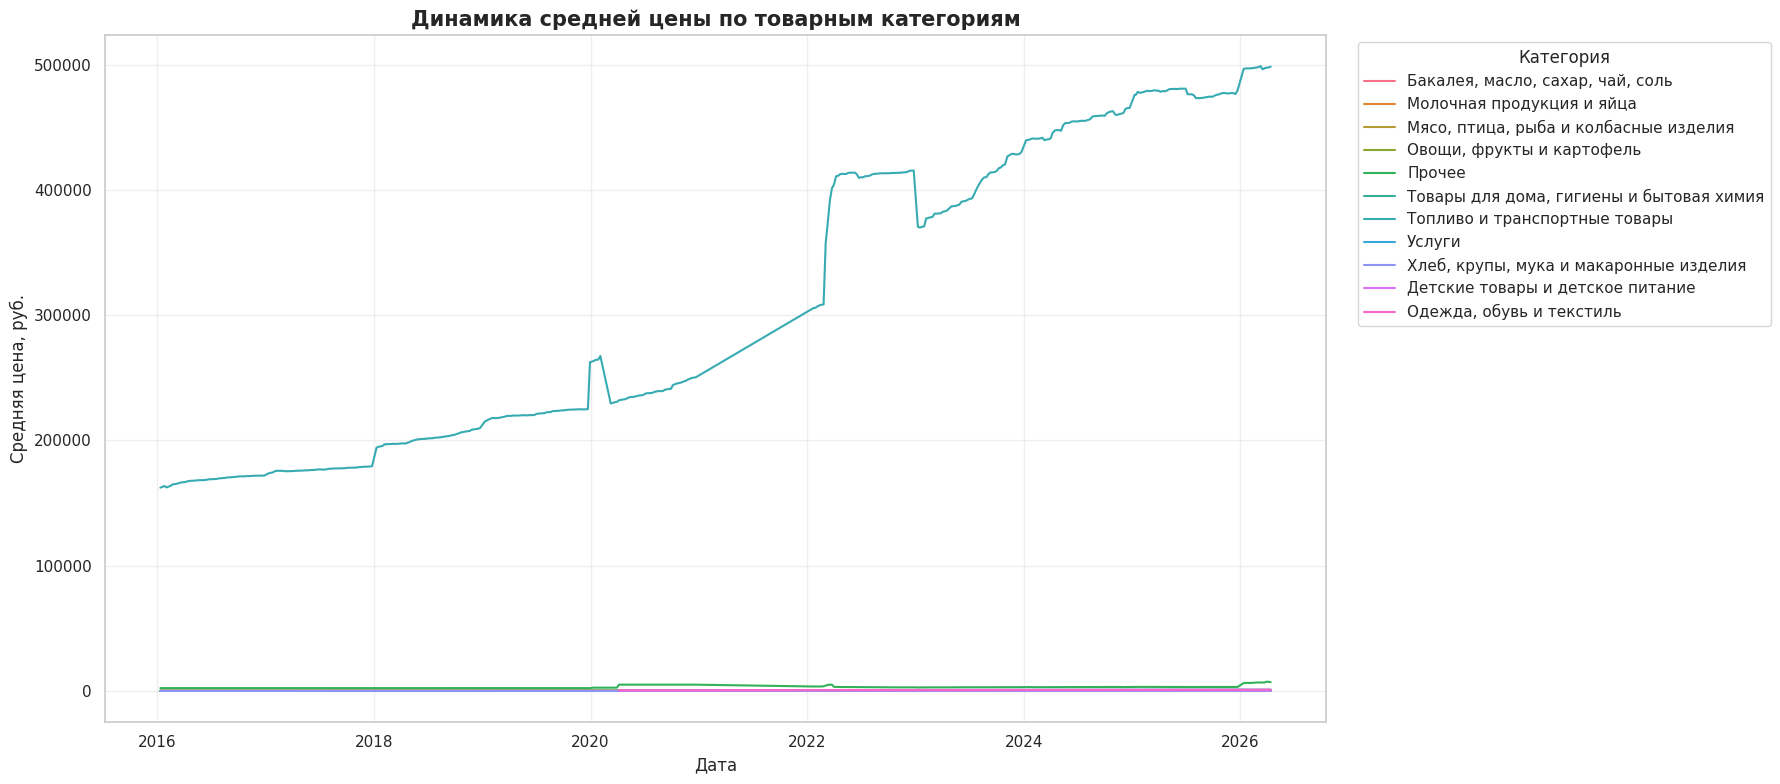

In [62]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(18, 8))

sns.lineplot(
    data=category_ts,
    x="date",
    y="mean_price",
    hue="product_group_name"
)

plt.title("Динамика средней цены по товарным категориям", fontsize=15, fontweight="bold")
plt.xlabel("Дата")
plt.ylabel("Средняя цена, руб.")
plt.legend(title="Категория", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

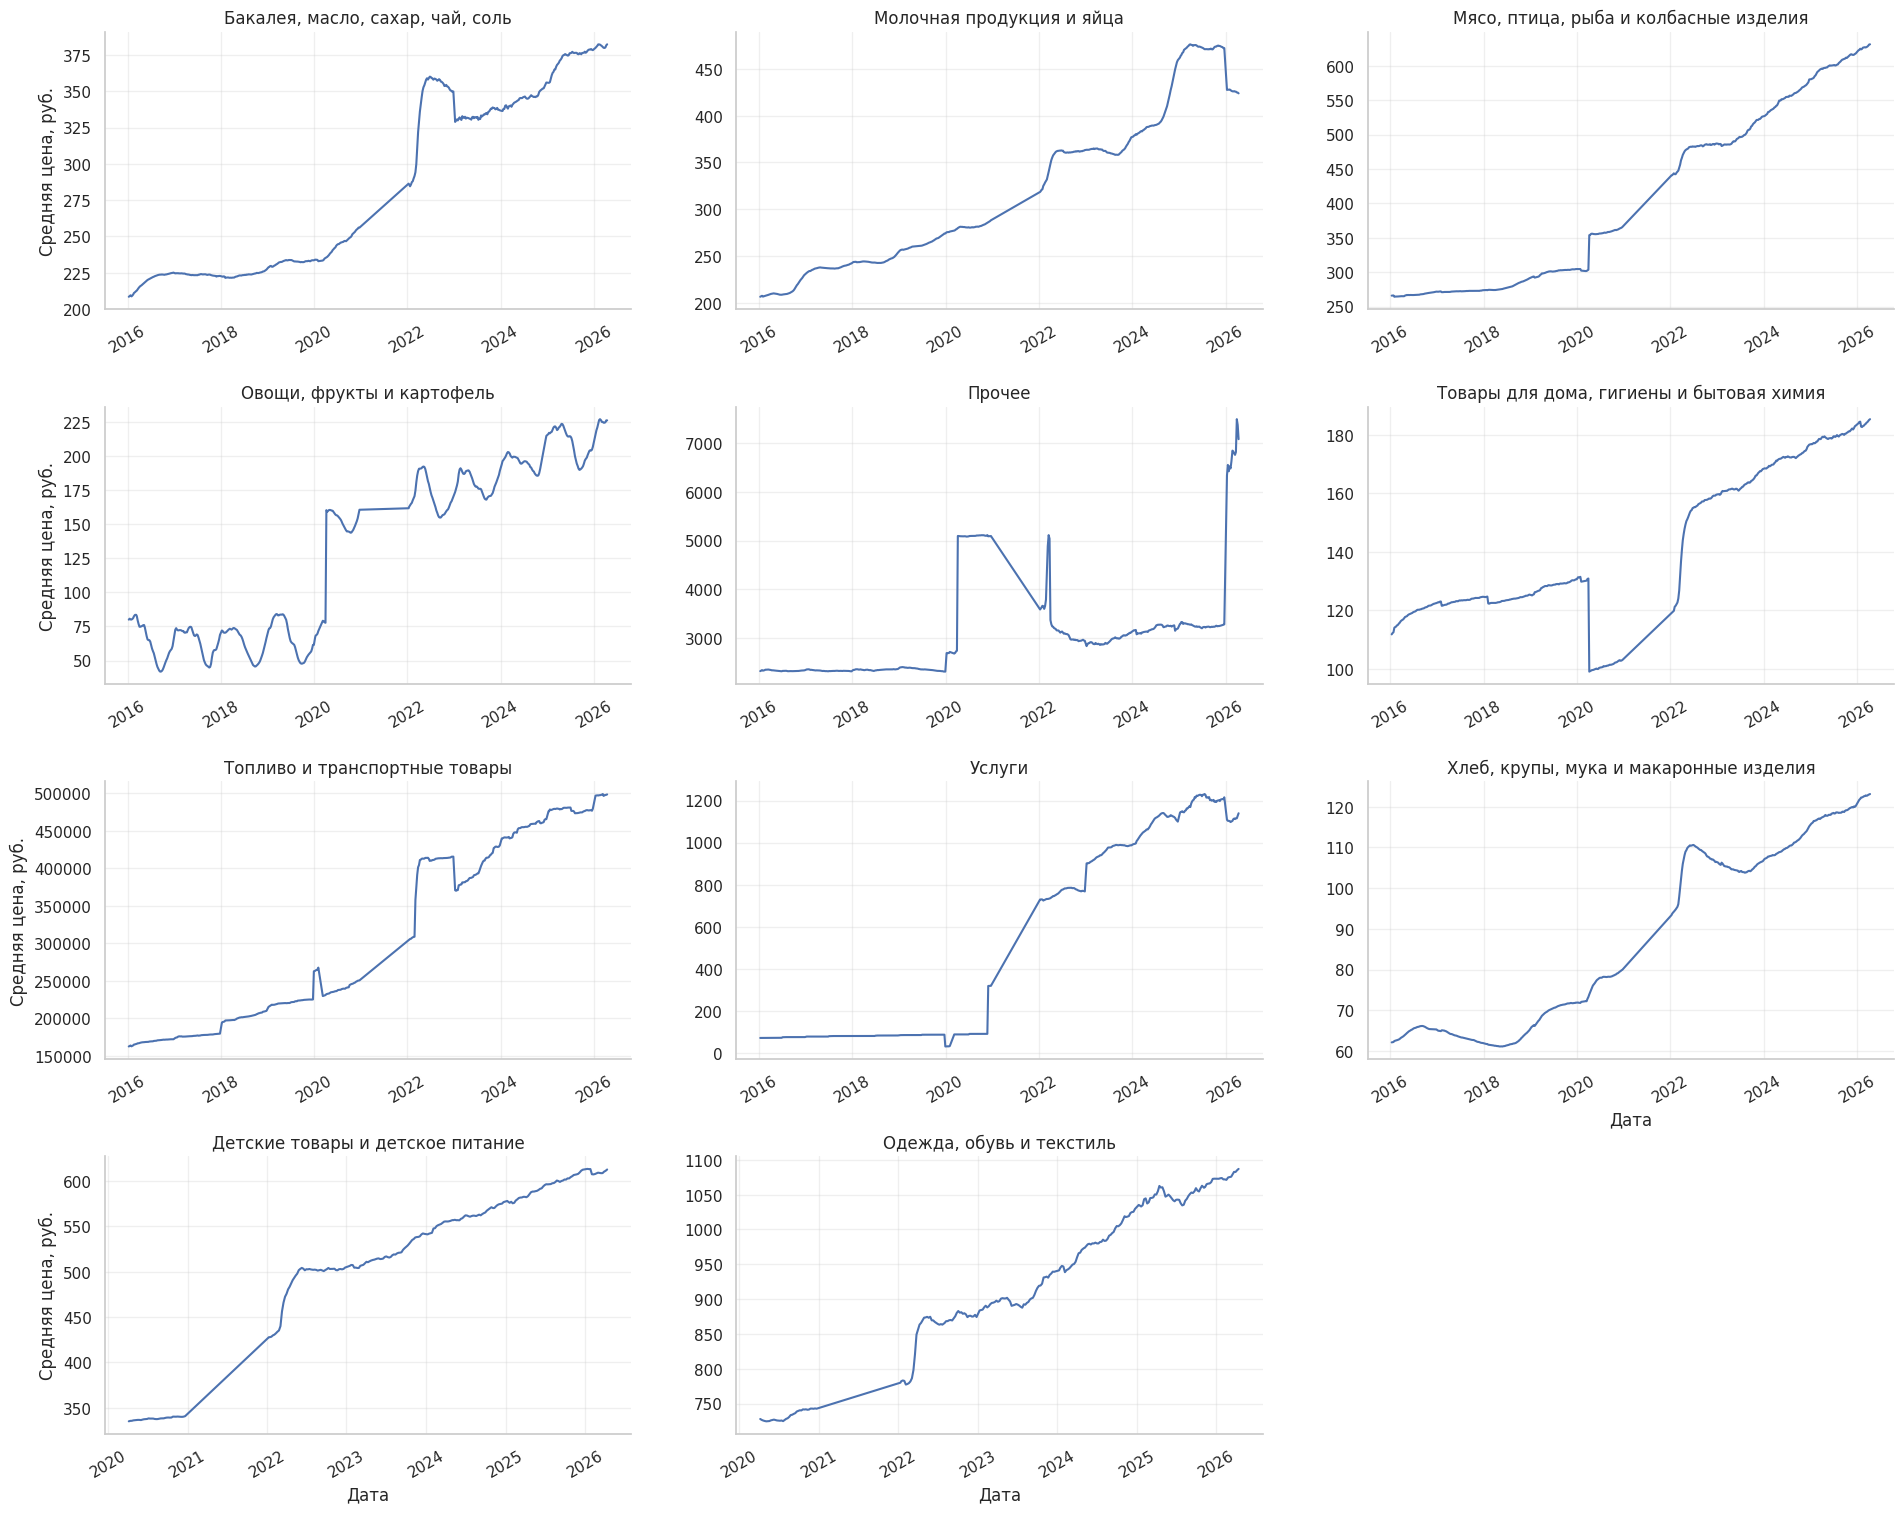

In [64]:
g = sns.FacetGrid(
    category_ts,
    col="product_group_name",
    col_wrap=3,
    height=4,
    aspect=1.6,
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="date",
    y="mean_price"
)

g.set_axis_labels("Дата", "Средняя цена, руб.")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.tick_params(axis="x", labelrotation=30)
    ax.grid(True, alpha=0.3)

plt.subplots_adjust(top=0.92, hspace=0.35, wspace=0.2)
plt.show()

In [65]:
OUT_DIR = Path("/content/drive/MyDrive/rostat/processed")

prices_long = pd.read_csv(
    OUT_DIR / "weekly_prices_long.csv",
    parse_dates=["date"]
)

products = pd.read_csv(
    OUT_DIR / "product_dictionary.csv"
)

prices_with_groups = prices_long.merge(
    products[
        [
            "product_code",
            "product_name",
            "unit",
            "product_group_code",
            "product_group_name"
        ]
    ],
    on="product_code",
    how="left"
)

prices_with_groups["year"] = prices_with_groups["date"].dt.year

print(prices_with_groups.shape)
prices_with_groups.head()

(42269, 10)


,date,year,product_code,price,source_file,source_sheet,product_name,unit,product_group_code,product_group_name
0,2016-01-11,2016,P0005,341.28,[2016-2020]_price_spred.xlsx,Данные,Баранина (кроме бескостного мяса),кг,G03,"Мясо, птица, рыба и колбасные изделия"
1,2016-01-11,2016,P0006,34.89,[2016-2020]_price_spred.xlsx,Данные,Бензин автомобильный,NaN,G10,Топливо и транспортные товары
2,2016-01-11,2016,P0007,32.23,[2016-2020]_price_spred.xlsx,Данные,Бензин автомобильный марки А-76 (АИ-80),л,G10,Топливо и транспортные товары
3,2016-01-11,2016,P0008,33.91,[2016-2020]_price_spred.xlsx,Данные,Бензин автомобильный марки АИ-92,л,G10,Топливо и транспортные товары
4,2016-01-11,2016,P0009,36.80,[2016-2020]_price_spred.xlsx,Данные,Бензин автомобильный марки АИ-95,л,G10,Топливо и транспортные товары


In [66]:
year_summary = (
    prices_with_groups
    .groupby("year", as_index=False)
    .agg(
        n_rows=("price", "size"),
        n_dates=("date", "nunique"),
        n_products=("product_code", "nunique"),
        n_categories=("product_group_name", "nunique"),
        mean_price=("price", "mean"),
        median_price=("price", "median")
    )
)

display(year_summary)

,year,n_rows,n_dates,n_products,n_categories,mean_price,median_price
0,2016,3468,51,68,9,17881.546018,81.925
1,2017,3468,51,68,9,18735.202105,78.615
2,2018,3400,50,68,9,21283.809997,83.045
3,2019,3534,52,68,9,23338.813359,89.850
4,2020,4562,47,107,11,18760.672753,144.285
5,2022,5457,51,108,11,26987.444163,171.180
6,2023,5610,51,110,11,30203.110184,207.720
7,2024,5606,51,110,11,34233.244930,218.980
8,2025,5610,51,110,11,36059.544784,235.345
9,2026,1554,14,112,11,38330.946570,254.205


In [67]:
category_year_summary = (
    prices_with_groups
    .groupby(["year", "product_group_name"], as_index=False)
    .agg(
        n_products=("product_code", "nunique"),
        n_dates=("date", "nunique"),
        mean_price=("price", "mean"),
        median_price=("price", "median")
    )
)

display(category_year_summary.sort_values(["product_group_name", "year"]))

,year,product_group_name,n_products,n_dates,mean_price,median_price
0,2016,"Бакалея, масло, сахар, чай, соль",7,51,219.251569,121.540
9,2017,"Бакалея, масло, сахар, чай, соль",7,51,223.697899,123.300
18,2018,"Бакалея, масло, сахар, чай, соль",7,50,223.475629,126.030
27,2019,"Бакалея, масло, сахар, чай, соль",7,52,232.271676,132.675
36,2020,"Бакалея, масло, сахар, чай, соль",7,47,243.831155,135.930
...,...,...,...,...,...,...
57,2022,"Хлеб, крупы, мука и макаронные изделия",9,51,105.634227,99.260
68,2023,"Хлеб, крупы, мука и макаронные изделия",9,51,104.996841,90.430
79,2024,"Хлеб, крупы, мука и макаронные изделия",9,51,110.279564,97.170
90,2025,"Хлеб, крупы, мука и макаронные изделия",9,51,118.198562,111.200


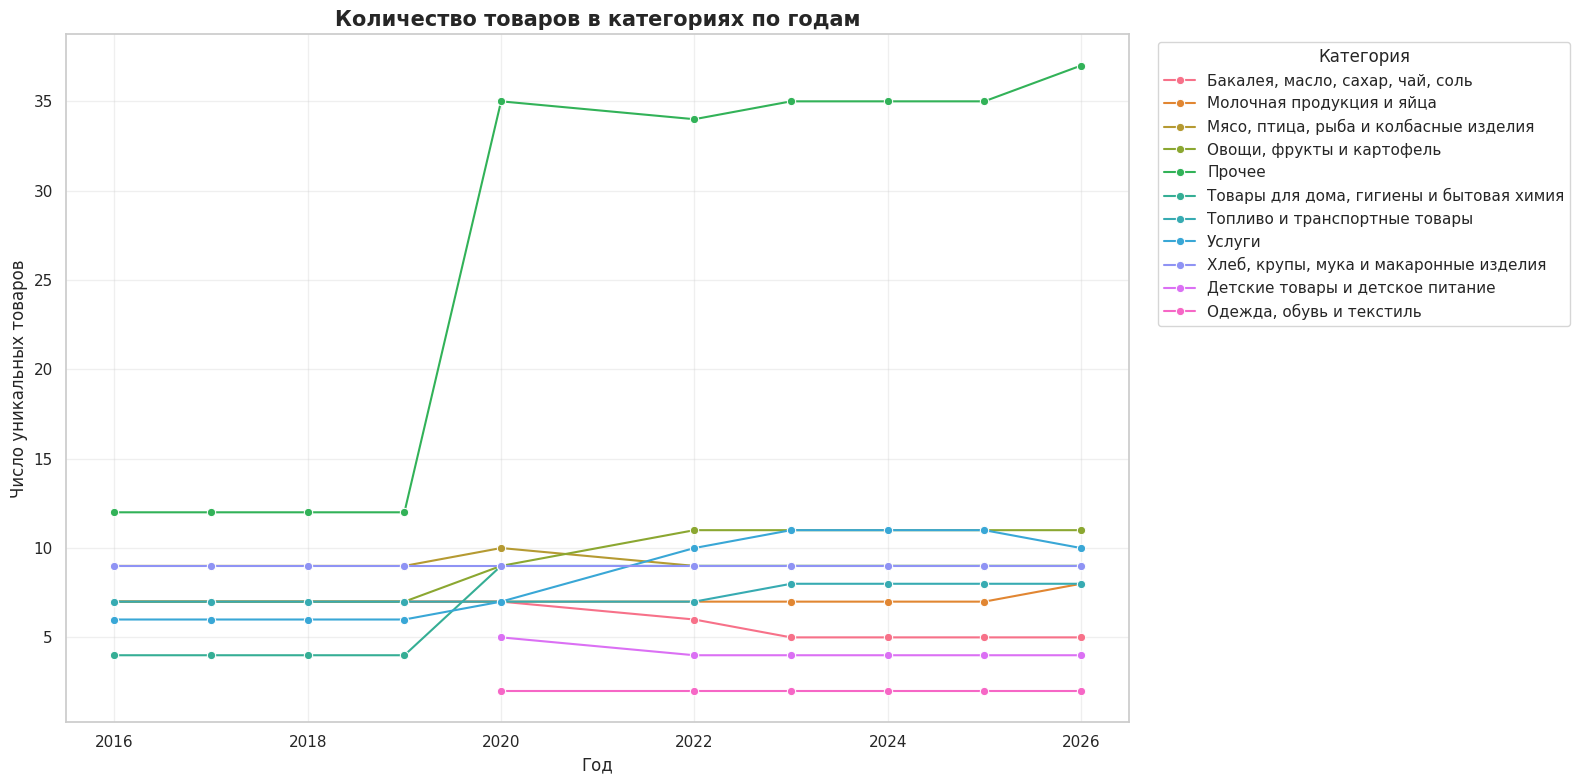

In [68]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(16, 8))

sns.lineplot(
    data=category_year_summary,
    x="year",
    y="n_products",
    hue="product_group_name",
    marker="o"
)

plt.title("Количество товаров в категориях по годам", fontsize=15, fontweight="bold")
plt.xlabel("Год")
plt.ylabel("Число уникальных товаров")
plt.legend(title="Категория", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

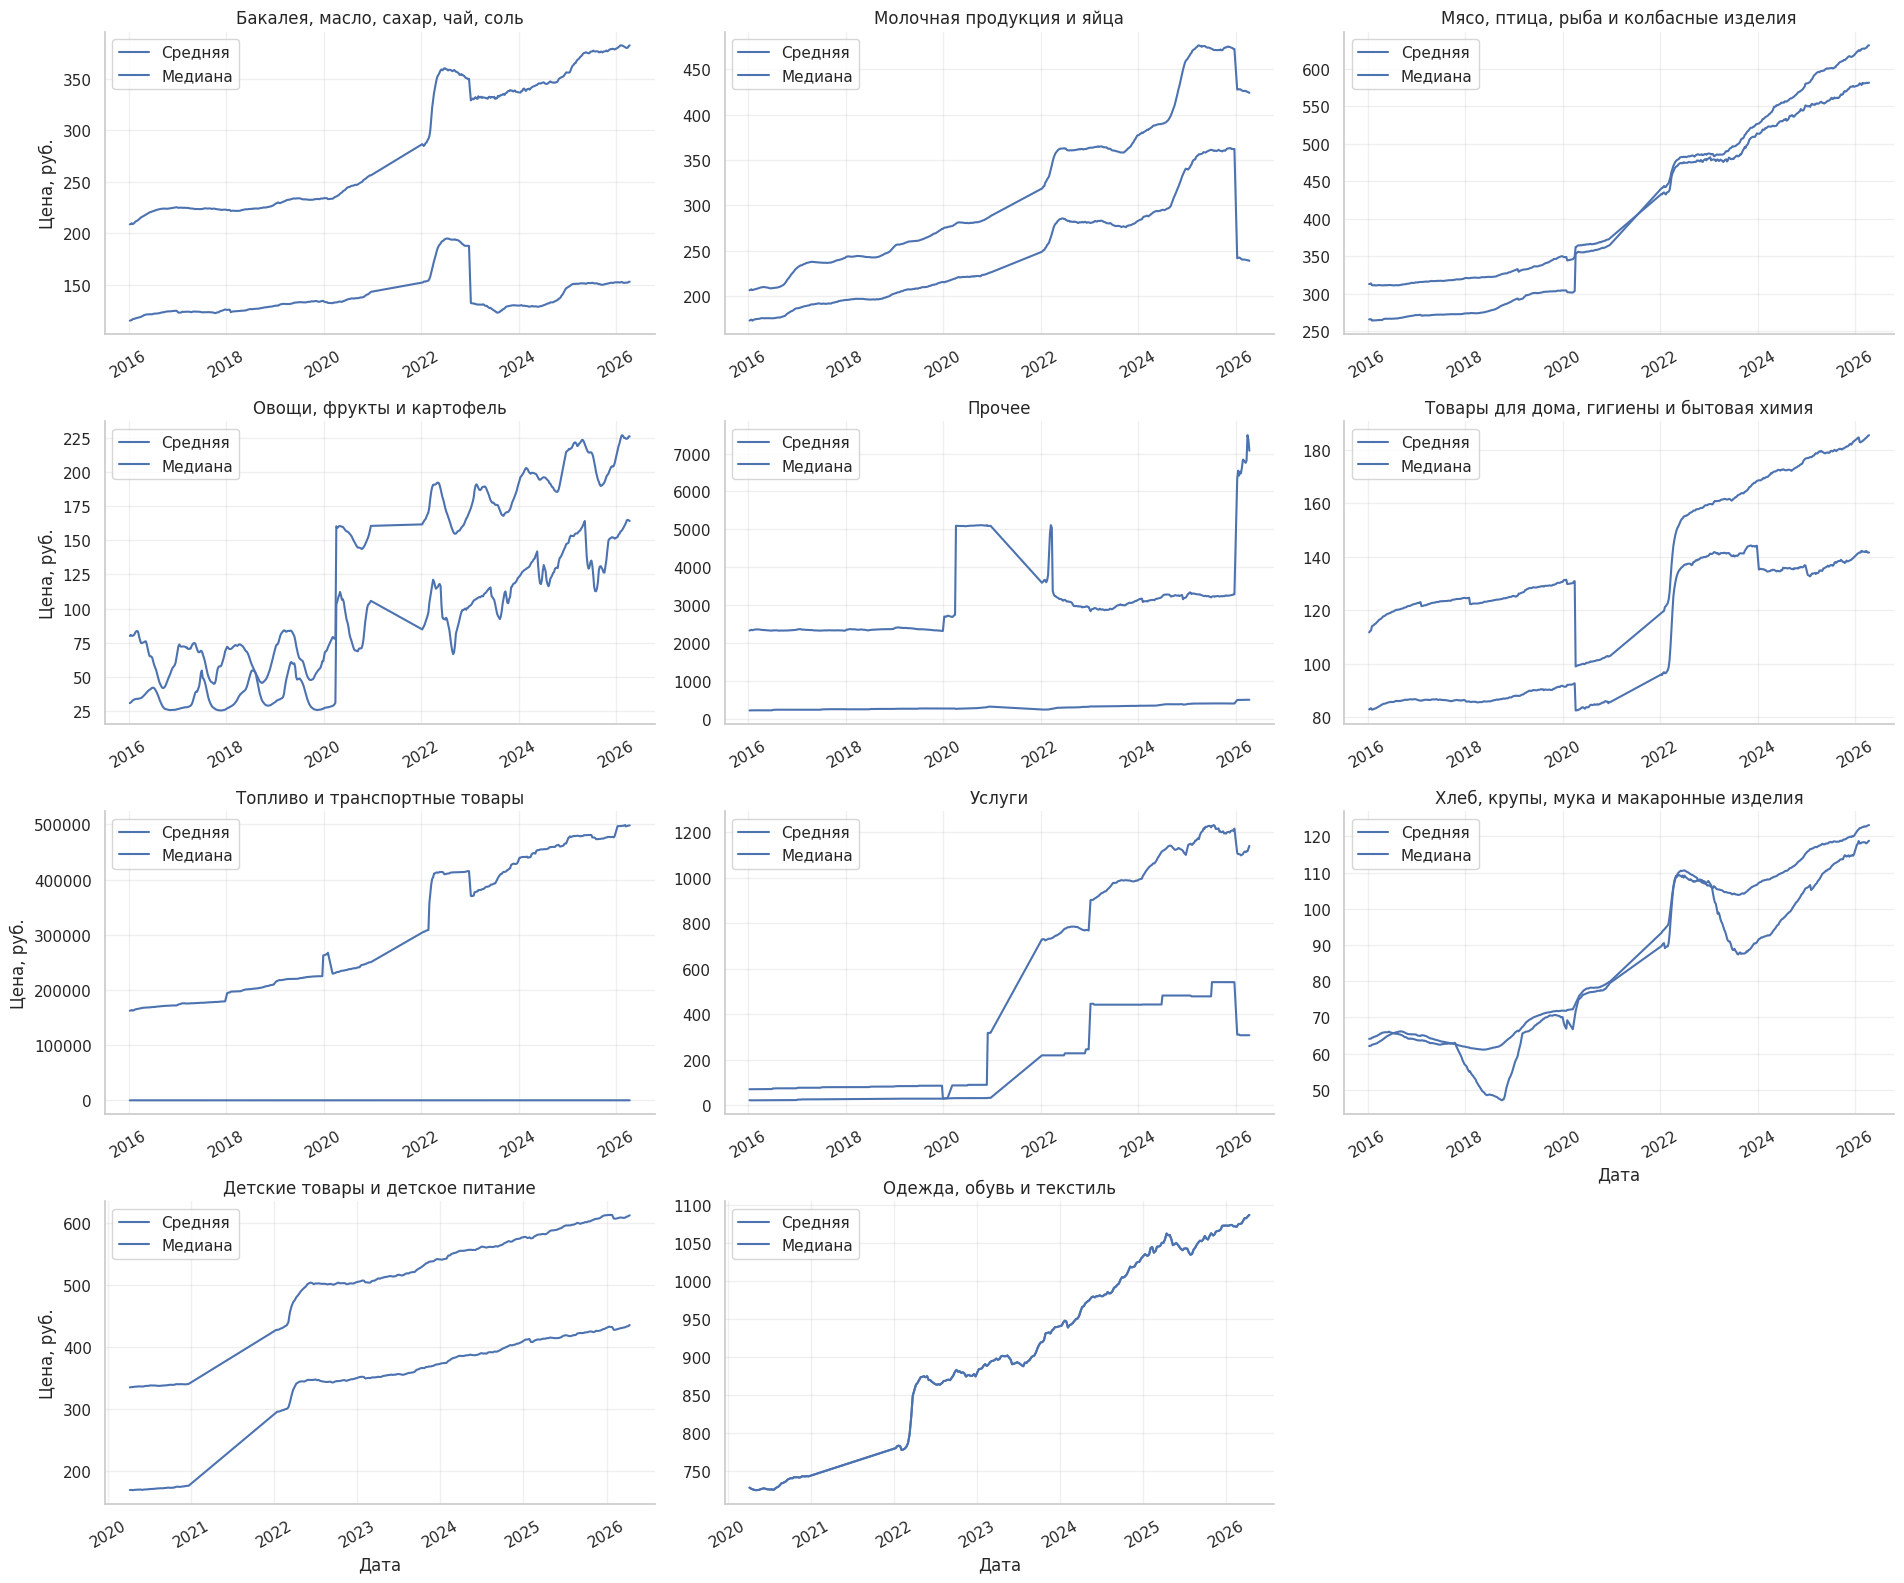

In [69]:
category_ts_compare = (
    prices_with_groups
    .groupby(["date", "product_group_name"], as_index=False)
    .agg(
        mean_price=("price", "mean"),
        median_price=("price", "median"),
        n_products=("product_code", "nunique")
    )
)

g = sns.FacetGrid(
    category_ts_compare,
    col="product_group_name",
    col_wrap=3,
    height=4,
    aspect=1.6,
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="date",
    y="mean_price",
    label="Средняя"
)

g.map_dataframe(
    sns.lineplot,
    x="date",
    y="median_price",
    label="Медиана"
)

g.set_axis_labels("Дата", "Цена, руб.")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.tick_params(axis="x", labelrotation=30)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

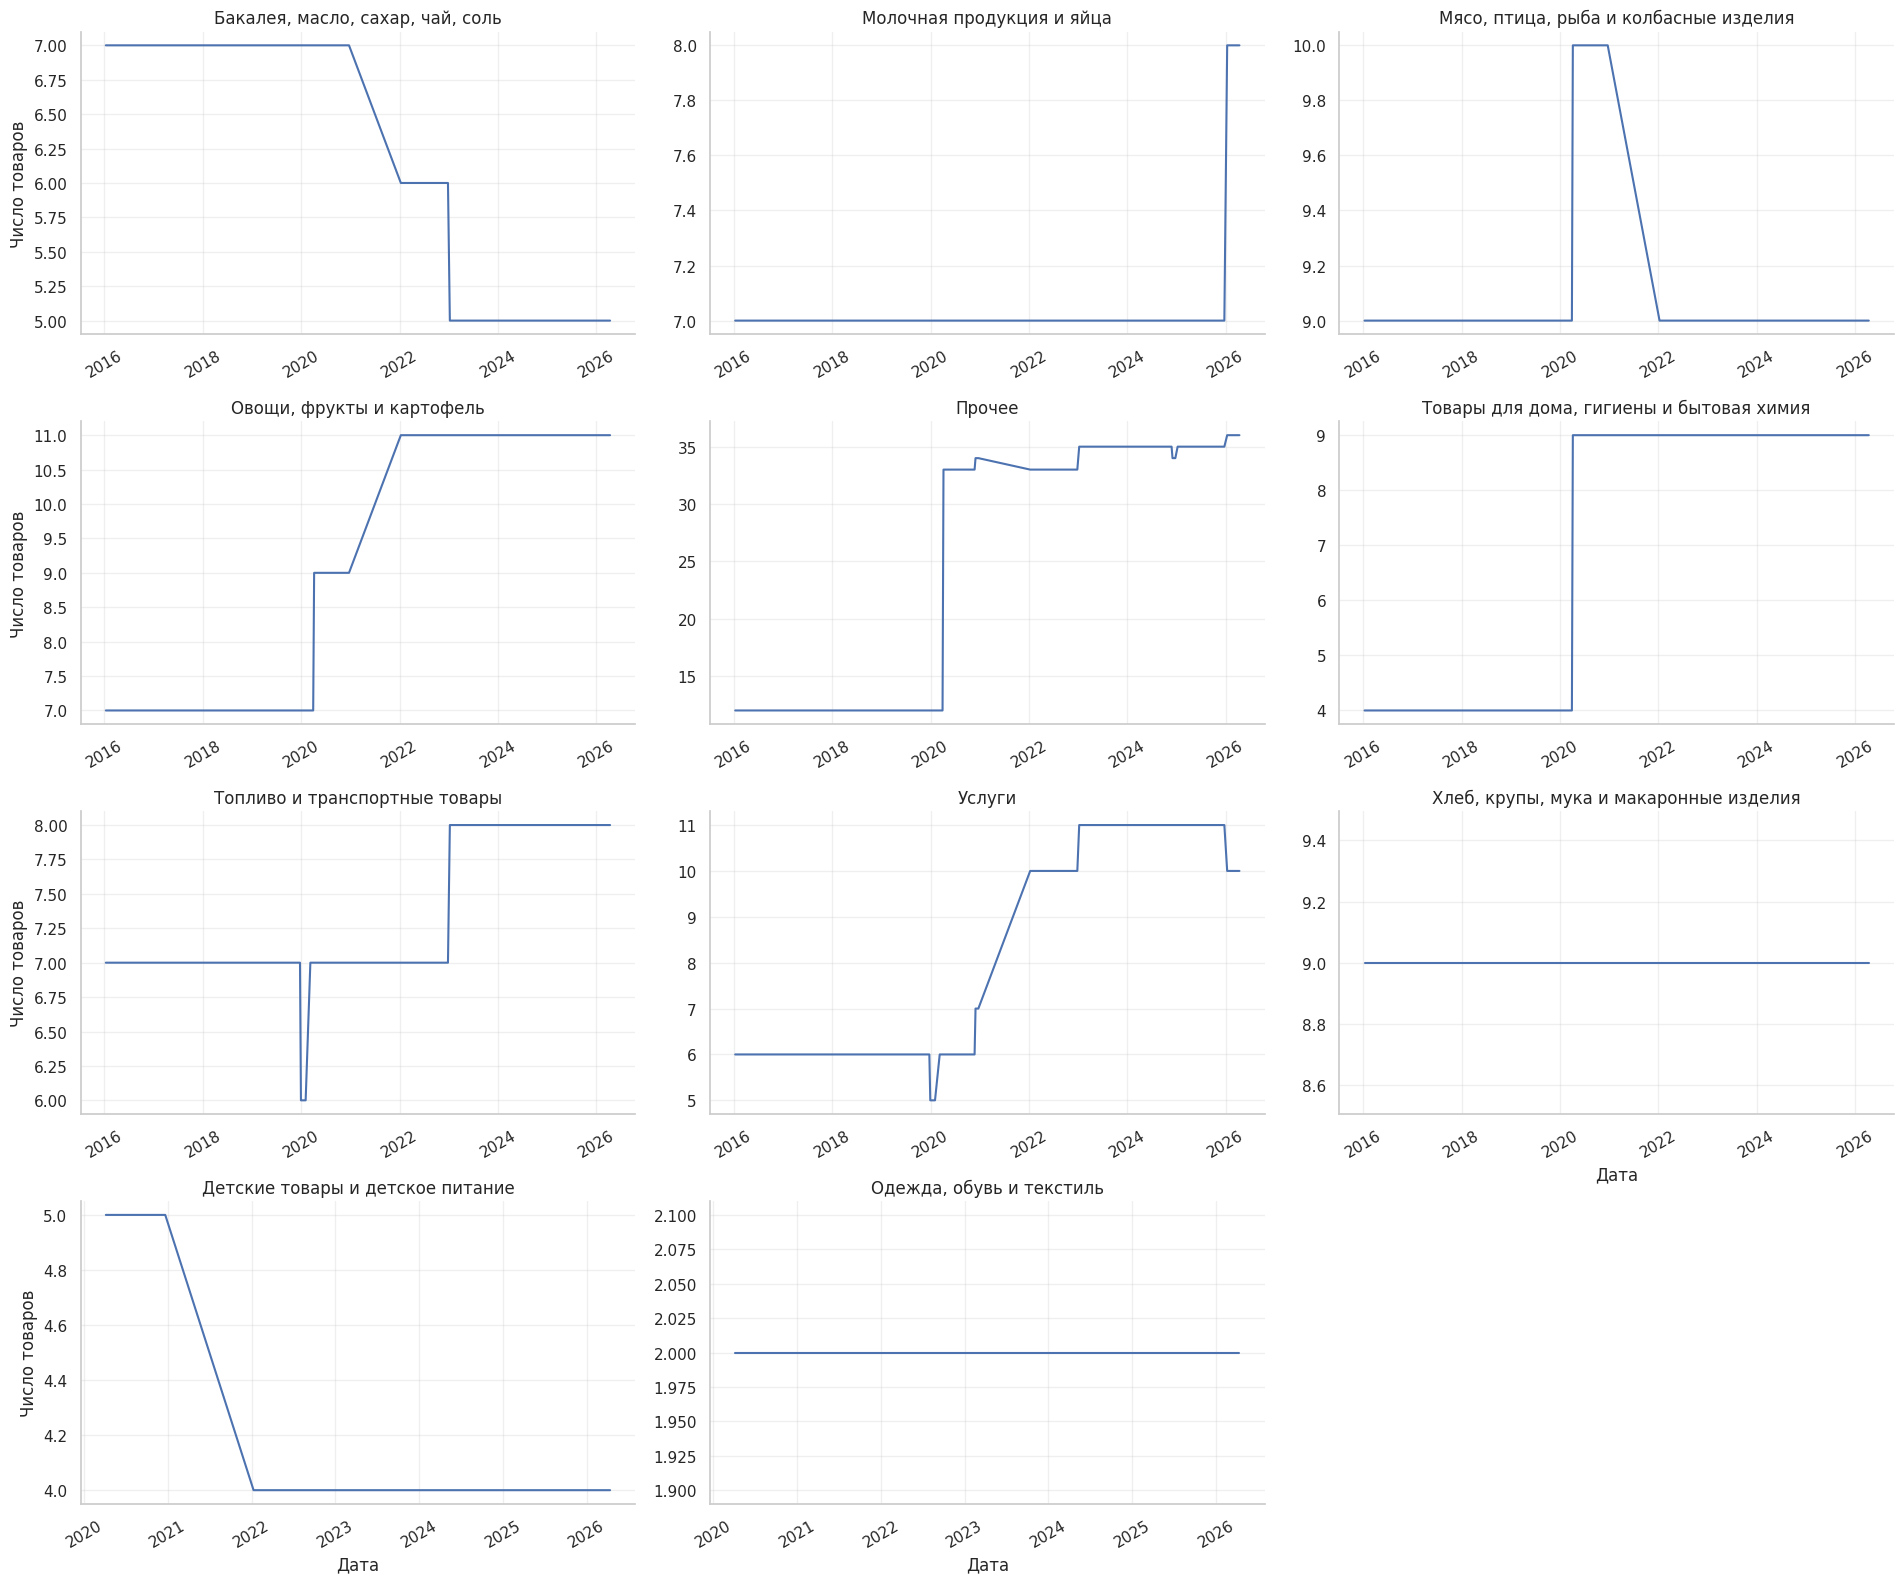

In [70]:
category_composition_ts = (
    prices_with_groups
    .groupby(["date", "product_group_name"], as_index=False)
    .agg(
        n_products=("product_code", "nunique")
    )
)

g = sns.FacetGrid(
    category_composition_ts,
    col="product_group_name",
    col_wrap=3,
    height=4,
    aspect=1.6,
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="date",
    y="n_products"
)

g.set_axis_labels("Дата", "Число товаров")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.tick_params(axis="x", labelrotation=30)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [71]:
product_jumps = (
    prices_with_groups
    .sort_values(["product_code", "date"])
    .copy()
)

product_jumps["prev_price"] = product_jumps.groupby("product_code")["price"].shift(1)
product_jumps["pct_change"] = (
    (product_jumps["price"] - product_jumps["prev_price"]) / product_jumps["prev_price"]
)

# Берём только резкие скачки, например > 50%
large_jumps = product_jumps[
    product_jumps["pct_change"].abs() > 0.5
].copy()

large_jumps = large_jumps[
    [
        "date",
        "product_code",
        "product_name",
        "product_group_name",
        "price",
        "prev_price",
        "pct_change",
        "source_file",
        "source_sheet"
    ]
].sort_values("pct_change", ascending=False)

display(large_jumps.head(50))

,date,product_code,product_name,product_group_name,price,prev_price,pct_change,source_file,source_sheet
18452,2022-01-10,P0031,Капуста белокочанная свежая,"Овощи, фрукты и картофель",56.31,20.73,1.716353,[2022-2026]_price_spred.xlsx,2022
40759,2026-01-12,P0064,Метамизол натрия,Прочее,41.39,18.52,1.234881,[2022-2026]_price_spred.xlsx,2026
18453,2022-01-10,P0033,Картофель,"Овощи, фрукты и картофель",47.42,28.57,0.659783,[2022-2026]_price_spred.xlsx,2022


In [72]:
duplicates_check = (
    prices_with_groups
    .groupby(["date", "product_code"], as_index=False)
    .agg(n_rows=("price", "size"))
)

duplicates_check = duplicates_check[
    duplicates_check["n_rows"] > 1
]

print("Количество дублей:", len(duplicates_check))
display(duplicates_check.head(20))

Количество дублей: 0


,date,product_code,n_rows


In [73]:
unit_check = (
    prices_with_groups
    .groupby("product_name", as_index=False)
    .agg(
        n_units=("unit", "nunique"),
        units=("unit", lambda x: ", ".join(sorted(set(x.dropna().astype(str)))))
    )
)

unit_issues = unit_check[unit_check["n_units"] > 1].copy()

print("Товаров с несколькими единицами измерения:", len(unit_issues))
display(unit_issues.head(50))

Товаров с несколькими единицами измерения: 4


,product_name,n_units,units
20,Водоснабжение горячее,2,"м3, месяц с человека"
59,Масло подсолнечное,2,"кг, л"
79,Отопление,2,"Гкал, м2 общей площади"
114,Ренгалин,2,"10 таблеток, 20 таблеток"


In [74]:
prices_with_groups["period_block"] = np.where(
    prices_with_groups["date"] < pd.Timestamp("2021-01-01"),
    "2016-2020",
    "2022-2026"
)

product_period_presence = (
    prices_with_groups
    .groupby(["product_code", "product_name", "product_group_name"], as_index=False)
    .agg(
        n_periods=("period_block", "nunique"),
        periods=("period_block", lambda x: ", ".join(sorted(set(x))))
    )
)

only_one_period = product_period_presence[
    product_period_presence["n_periods"] == 1
].copy()

print("Товаров, присутствующих только в одном из блоков:", len(only_one_period))
display(only_one_period.head(50))

Товаров, присутствующих только в одном из блоков: 77


,product_code,product_name,product_group_name,n_periods,periods
0,P0001,Активированный уголь,Прочее,1,2022-2026
1,P0002,Аллохол,Прочее,1,2022-2026
2,P0003,"Алмагель, суспензия",Прочее,1,2016-2020
3,P0004,Бананы,"Овощи, фрукты и картофель",1,2022-2026
6,P0007,Бензин автомобильный марки А-76 (АИ-80),Топливо и транспортные товары,1,2016-2020
10,P0011,"Бромгексин, 8 мг",Прочее,1,2016-2020
13,P0014,Валидол,Прочее,1,2022-2026
14,P0015,"Валидол, 60 мг",Прочее,1,2022-2026
15,P0016,Валокордин,Прочее,1,2016-2020
17,P0018,Водка,Прочее,1,2022-2026


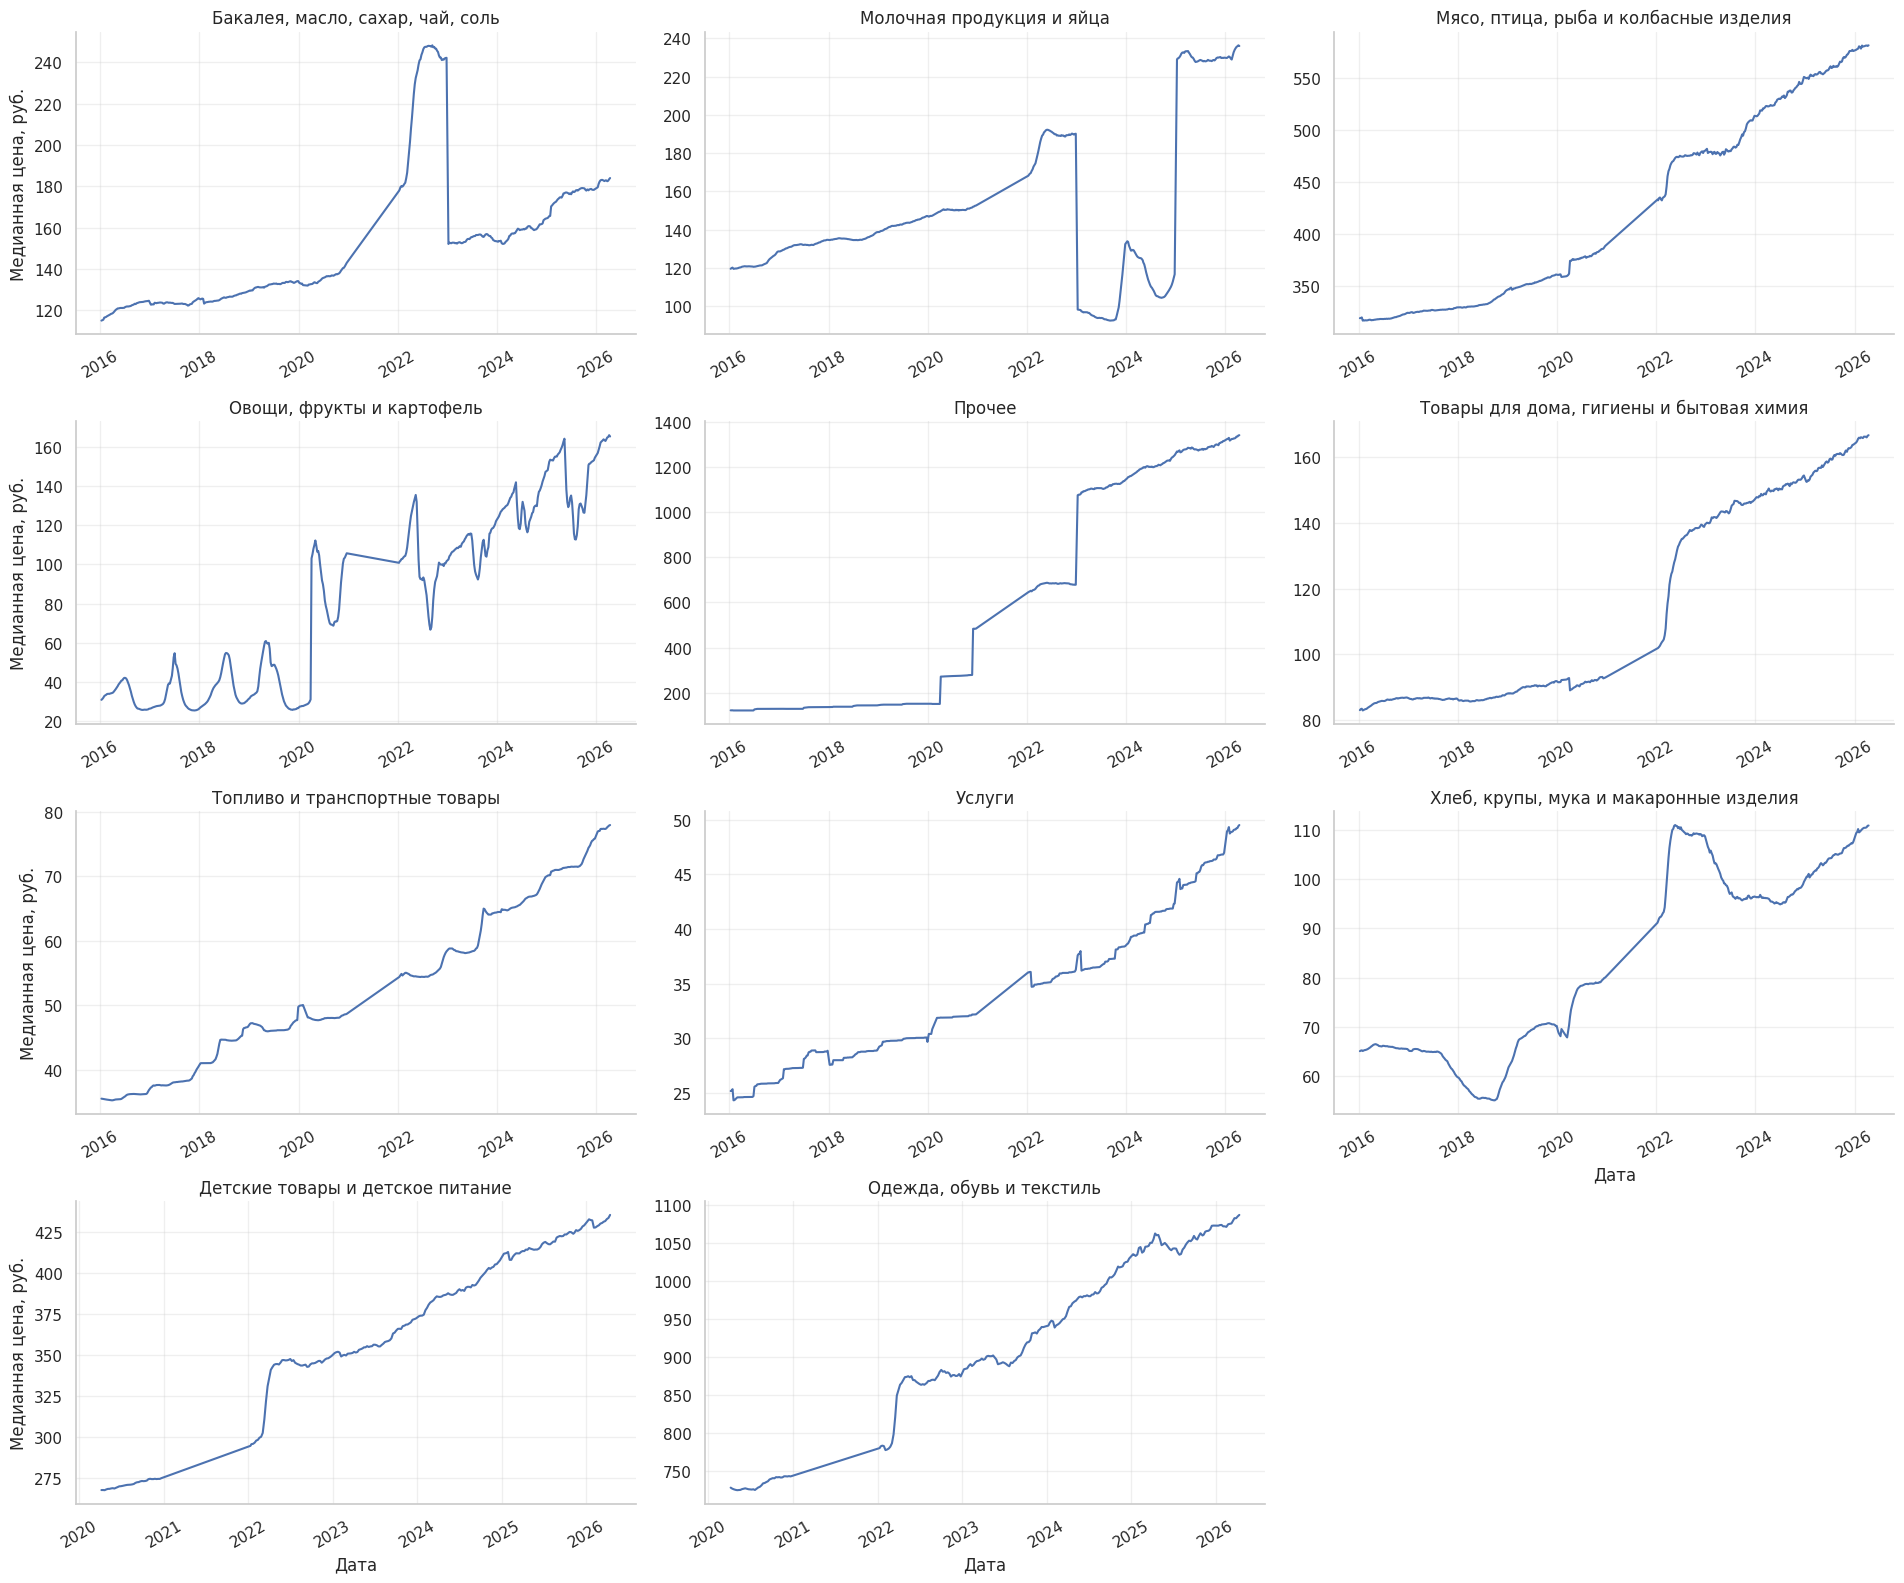

In [75]:
stable_products = product_period_presence[
    product_period_presence["n_periods"] == 2
]["product_code"].unique()

prices_stable = prices_with_groups[
    prices_with_groups["product_code"].isin(stable_products)
].copy()

category_ts_stable = (
    prices_stable
    .groupby(["date", "product_group_name"], as_index=False)
    .agg(
        mean_price=("price", "mean"),
        median_price=("price", "median"),
        n_products=("product_code", "nunique")
    )
)

g = sns.FacetGrid(
    category_ts_stable,
    col="product_group_name",
    col_wrap=3,
    height=4,
    aspect=1.6,
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="date",
    y="median_price"
)

g.set_axis_labels("Дата", "Медианная цена, руб.")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.tick_params(axis="x", labelrotation=30)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [76]:
OUT_DIR = Path("/content/drive/MyDrive/rostat/processed")

prices_long = pd.read_csv(
    OUT_DIR / "weekly_prices_long.csv",
    parse_dates=["date"]
)

products = pd.read_csv(
    OUT_DIR / "product_dictionary.csv"
)

product_groups = pd.read_csv(
    OUT_DIR / "product_groups.csv"
)

duplicates_report = pd.read_csv(
    OUT_DIR / "duplicates_report.csv"
)

prices_long["year"] = prices_long["date"].dt.year

prices_with_groups = prices_long.merge(
    products[
        [
            "product_code",
            "product_key",
            "product_name",
            "unit",
            "product_group_code",
            "product_group_name"
        ]
    ],
    on="product_code",
    how="left"
)

prices_with_groups["period_block"] = np.select(
    [
        prices_with_groups["year"].between(2016, 2020),
        prices_with_groups["year"].between(2022, 2026)
    ],
    [
        "2016-2020",
        "2022-2026"
    ],
    default="other"
)

period_check = (
    prices_with_groups
    .groupby(["product_group_code", "product_group_name"], as_index=False)
    .agg(
        periods=("period_block", lambda x: ", ".join(sorted(set(x) - {"other"}))),
        n_products=("product_code", "nunique"),
        n_rows=("price", "size")
    )
)

common_groups = period_check[
    period_check["periods"].apply(
        lambda x: "2016-2020" in x and "2022-2026" in x
    )
].copy()

common_group_codes = common_groups["product_group_code"].unique()

print("Категории, которые останутся:")
display(common_groups.sort_values("product_group_code"))

Категории, которые останутся:


,product_group_code,product_group_name,periods,n_products,n_rows
0,G01,"Хлеб, крупы, мука и макаронные изделия","2016-2020, 2022-2026",10,4221
1,G02,Молочная продукция и яйца,"2016-2020, 2022-2026",11,3297
2,G03,"Мясо, птица, рыба и колбасные изделия","2016-2020, 2022-2026",10,4259
3,G04,"Овощи, фрукты и картофель","2016-2020, 2022-2026",11,4231
4,G05,"Бакалея, масло, сахар, чай, соль","2016-2020, 2022-2026",8,2898
5,G06,Детские товары и детское питание,"2016-2020, 2022-2026",5,1062
6,G07,"Товары для дома, гигиены и бытовая химия","2016-2020, 2022-2026",10,3156
7,G09,"Одежда, обувь и текстиль","2016-2020, 2022-2026",2,512
8,G10,Топливо и транспортные товары,"2016-2020, 2022-2026",10,3444
9,G11,Услуги,"2016-2020, 2022-2026",13,3837


In [77]:
products_filtered = products[
    products["product_group_code"].isin(common_group_codes)
].copy()

product_groups_filtered = product_groups[
    product_groups["product_group_code"].isin(common_group_codes)
].copy()

common_product_codes = products_filtered["product_code"].unique()
common_product_keys = products_filtered["product_key"].unique()

prices_long_filtered = prices_long[
    prices_long["product_code"].isin(common_product_codes)
].copy()

duplicates_report_filtered = duplicates_report[
    duplicates_report["product_key"].isin(common_product_keys)
].copy()

In [78]:
prices_wide_filtered = (
    prices_long_filtered
    .pivot_table(
        index="date",
        columns="product_code",
        values="price",
        aggfunc="mean"
    )
    .reset_index()
)

prices_wide_filtered.columns.name = None

In [79]:
prices_long_filtered.to_csv(
    OUT_DIR / "weekly_prices_long.csv",
    index=False,
    encoding="utf-8-sig"
)

prices_wide_filtered.to_csv(
    OUT_DIR / "weekly_prices_wide.csv",
    index=False,
    encoding="utf-8-sig"
)

products_filtered.to_csv(
    OUT_DIR / "product_dictionary.csv",
    index=False,
    encoding="utf-8-sig"
)

product_groups_filtered.to_csv(
    OUT_DIR / "product_groups.csv",
    index=False,
    encoding="utf-8-sig"
)

duplicates_report_filtered.to_csv(
    OUT_DIR / "duplicates_report.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Файлы перезаписаны в:", OUT_DIR)

Файлы перезаписаны в: /content/drive/MyDrive/rostat/processed


In [80]:
prices_long_check = pd.read_csv(
    OUT_DIR / "weekly_prices_long.csv",
    parse_dates=["date"]
)

products_check = pd.read_csv(
    OUT_DIR / "product_dictionary.csv"
)

print("Проверка после фильтрации")

print("\nweekly_prices_long.csv:")
print(prices_long_check.shape)
print("Период:", prices_long_check["date"].min(), "—", prices_long_check["date"].max())
print("Товаров:", prices_long_check["product_code"].nunique())

print("\nproduct_dictionary.csv:")
print(products_check.shape)
print("Категорий:", products_check["product_group_code"].nunique())

print("\nНаблюдения по годам:")
display(
    prices_long_check
    .assign(year=prices_long_check["date"].dt.year)
    .groupby("year")
    .agg(
        rows=("price", "size"),
        dates=("date", "nunique"),
        products=("product_code", "nunique")
    )
    .reset_index()
)

print("\nРаспределение товаров по категориям:")
display(
    products_check
    .groupby(["product_group_code", "product_group_name"], as_index=False)
    .agg(products_count=("product_code", "nunique"))
    .sort_values("product_group_code")
)

Проверка после фильтрации

weekly_prices_long.csv:
(42269, 6)
Период: 2016-01-11 00:00:00 — 2026-04-13 00:00:00
Товаров: 159

product_dictionary.csv:
(159, 7)
Категорий: 11

Наблюдения по годам:


,year,rows,dates,products
0,2016,3468,51,68
1,2017,3468,51,68
2,2018,3400,50,68
3,2019,3534,52,68
4,2020,4562,47,107
5,2022,5457,51,108
6,2023,5610,51,110
7,2024,5606,51,110
8,2025,5610,51,110
9,2026,1554,14,112



Распределение товаров по категориям:


,product_group_code,product_group_name,products_count
0,G01,"Хлеб, крупы, мука и макаронные изделия",10
1,G02,Молочная продукция и яйца,11
2,G03,"Мясо, птица, рыба и колбасные изделия",10
3,G04,"Овощи, фрукты и картофель",11
4,G05,"Бакалея, масло, сахар, чай, соль",8
5,G06,Детские товары и детское питание,5
6,G07,"Товары для дома, гигиены и бытовая химия",10
7,G09,"Одежда, обувь и текстиль",2
8,G10,Топливо и транспортные товары,10
9,G11,Услуги,13


In [83]:
OUT_DIR = Path("/content/drive/MyDrive/rostat/processed")

prices_long = pd.read_csv(
    OUT_DIR / "weekly_prices_long.csv",
    parse_dates=["date"]
)

products = pd.read_csv(
    OUT_DIR / "product_dictionary.csv"
)

prices_plot = prices_long.merge(
    products[
        [
            "product_code",
            "product_name",
            "product_group_code",
            "product_group_name"
        ]
    ],
    on="product_code",
    how="left"
)

prices_plot["year"] = prices_plot["date"].dt.year

prices_plot.head()

,date,year,product_code,price,source_file,source_sheet,product_name,product_group_code,product_group_name
0,2016-01-11,2016,P0005,341.28,[2016-2020]_price_spred.xlsx,Данные,Баранина (кроме бескостного мяса),G03,"Мясо, птица, рыба и колбасные изделия"
1,2016-01-11,2016,P0006,34.89,[2016-2020]_price_spred.xlsx,Данные,Бензин автомобильный,G10,Топливо и транспортные товары
2,2016-01-11,2016,P0007,32.23,[2016-2020]_price_spred.xlsx,Данные,Бензин автомобильный марки А-76 (АИ-80),G10,Топливо и транспортные товары
3,2016-01-11,2016,P0008,33.91,[2016-2020]_price_spred.xlsx,Данные,Бензин автомобильный марки АИ-92,G10,Топливо и транспортные товары
4,2016-01-11,2016,P0009,36.80,[2016-2020]_price_spred.xlsx,Данные,Бензин автомобильный марки АИ-95,G10,Топливо и транспортные товары


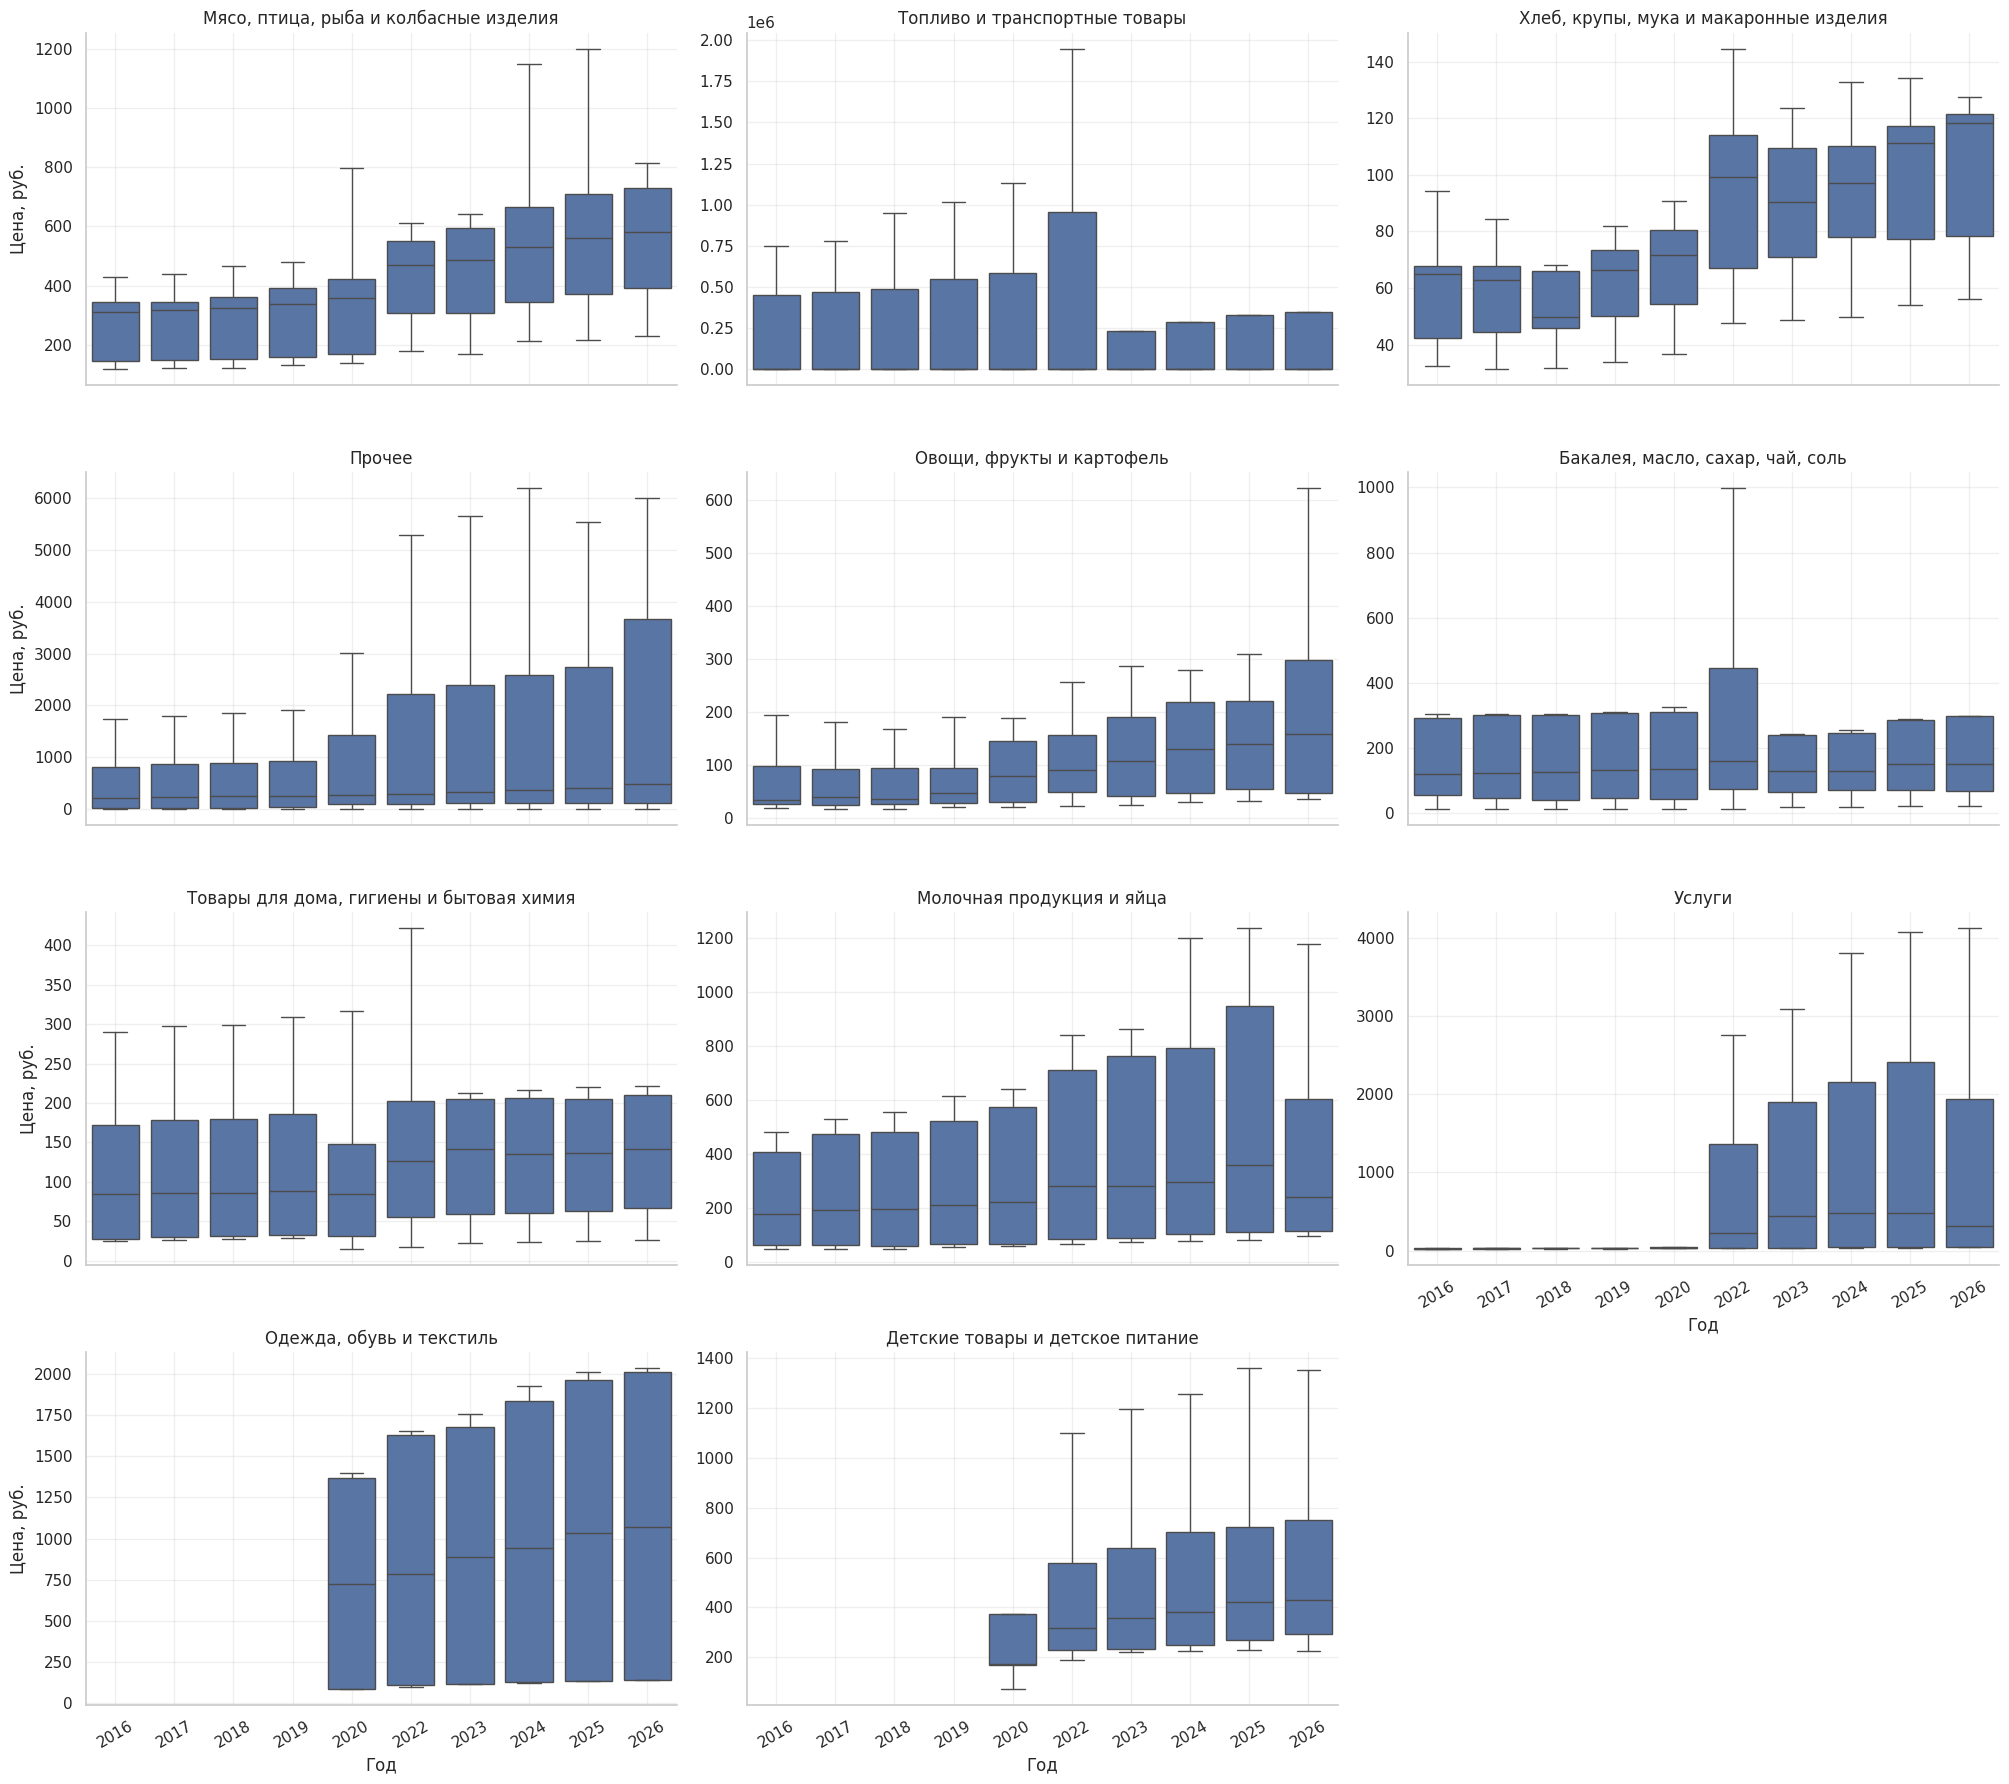

In [84]:
sns.set_theme(style="whitegrid")

g = sns.FacetGrid(
    prices_plot,
    col="product_group_name",
    col_wrap=3,
    height=4.5,
    aspect=1.5,
    sharey=False
)

g.map_dataframe(
    sns.boxplot,
    x="year",
    y="price",
    order=sorted(prices_plot["year"].unique()),
    showfliers=False
)

g.set_axis_labels("Год", "Цена, руб.")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

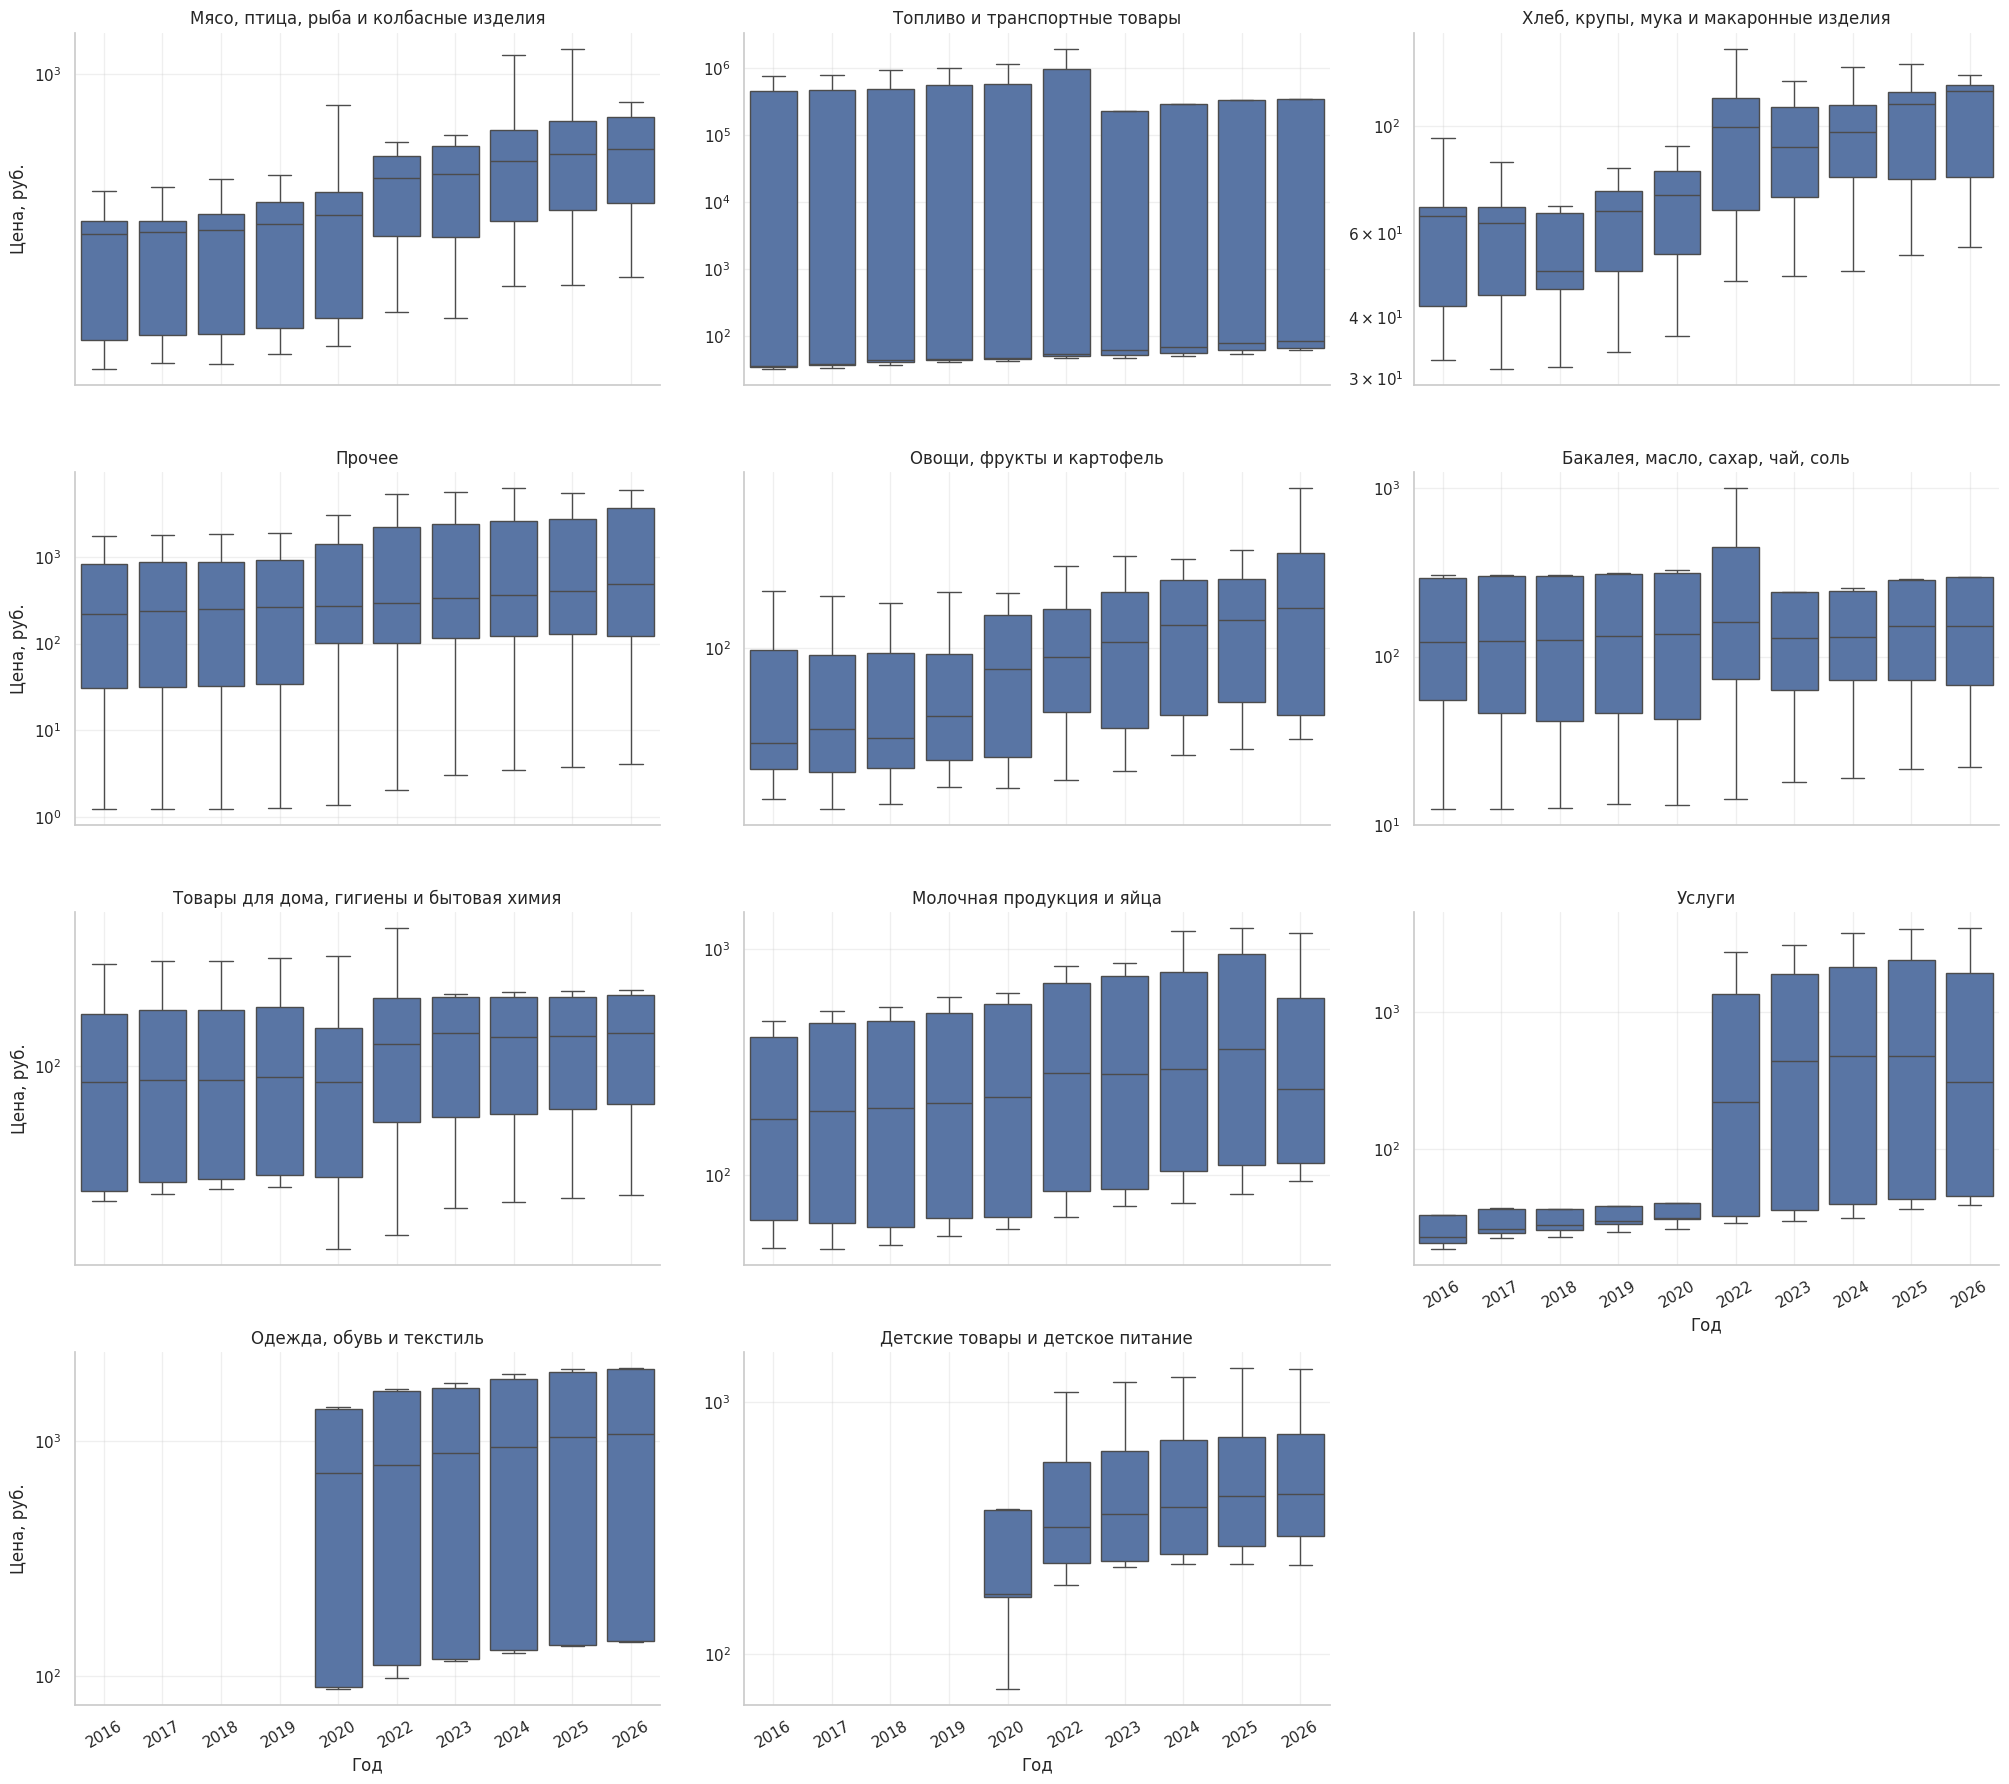

In [86]:
sns.set_theme(style="whitegrid")

g = sns.FacetGrid(
    prices_plot,
    col="product_group_name",
    col_wrap=3,
    height=4.5,
    aspect=1.5,
    sharey=False
)

g.map_dataframe(
    sns.boxplot,
    x="year",
    y="price",
    order=sorted(prices_plot["year"].unique()),
    showfliers=False
)

g.set_axis_labels("Год", "Цена, руб.")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.set_yscale("log")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [87]:
coverage_check = (
    prices_plot
    .groupby(["product_group_name", "year"], as_index=False)
    .agg(
        n_rows=("price", "size"),
        n_dates=("date", "nunique"),
        n_products=("product_code", "nunique"),
        min_date=("date", "min"),
        max_date=("date", "max")
    )
    .sort_values(["product_group_name", "year"])
)

display(coverage_check)

,product_group_name,year,n_rows,n_dates,n_products,min_date,max_date
0,"Бакалея, масло, сахар, чай, соль",2016,357,51,7,2016-01-11,2016-12-26
1,"Бакалея, масло, сахар, чай, соль",2017,357,51,7,2017-01-09,2017-12-25
2,"Бакалея, масло, сахар, чай, соль",2018,350,50,7,2018-01-09,2018-12-24
3,"Бакалея, масло, сахар, чай, соль",2019,364,52,7,2019-01-09,2019-12-30
4,"Бакалея, масло, сахар, чай, соль",2020,329,47,7,2020-01-09,2020-12-21
...,...,...,...,...,...,...,...
97,"Хлеб, крупы, мука и макаронные изделия",2022,459,51,9,2022-01-10,2022-12-26
98,"Хлеб, крупы, мука и макаронные изделия",2023,459,51,9,2023-01-09,2023-12-25
99,"Хлеб, крупы, мука и макаронные изделия",2024,459,51,9,2024-01-09,2024-12-23
100,"Хлеб, крупы, мука и макаронные изделия",2025,459,51,9,2025-01-09,2025-12-22


In [88]:
coverage_pivot = (
    coverage_check
    .pivot_table(
        index="product_group_name",
        columns="year",
        values="n_products",
        aggfunc="sum"
    )
    .fillna(0)
    .astype(int)
)

display(coverage_pivot)

year,2016,2017,2018,2019,2020,2022,2023,2024,2025,2026
product_group_name,,,,,,,,,,
"Бакалея, масло, сахар, чай, соль",7,7,7,7,7,6,5,5,5,5
Детские товары и детское питание,0,0,0,0,5,4,4,4,4,4
Молочная продукция и яйца,7,7,7,7,7,7,7,7,7,8
"Мясо, птица, рыба и колбасные изделия",9,9,9,9,10,9,9,9,9,9
"Овощи, фрукты и картофель",7,7,7,7,9,11,11,11,11,11
"Одежда, обувь и текстиль",0,0,0,0,2,2,2,2,2,2
Прочее,12,12,12,12,35,34,35,35,35,37
"Товары для дома, гигиены и бытовая химия",4,4,4,4,9,9,9,9,9,9
Топливо и транспортные товары,7,7,7,7,7,7,8,8,8,8


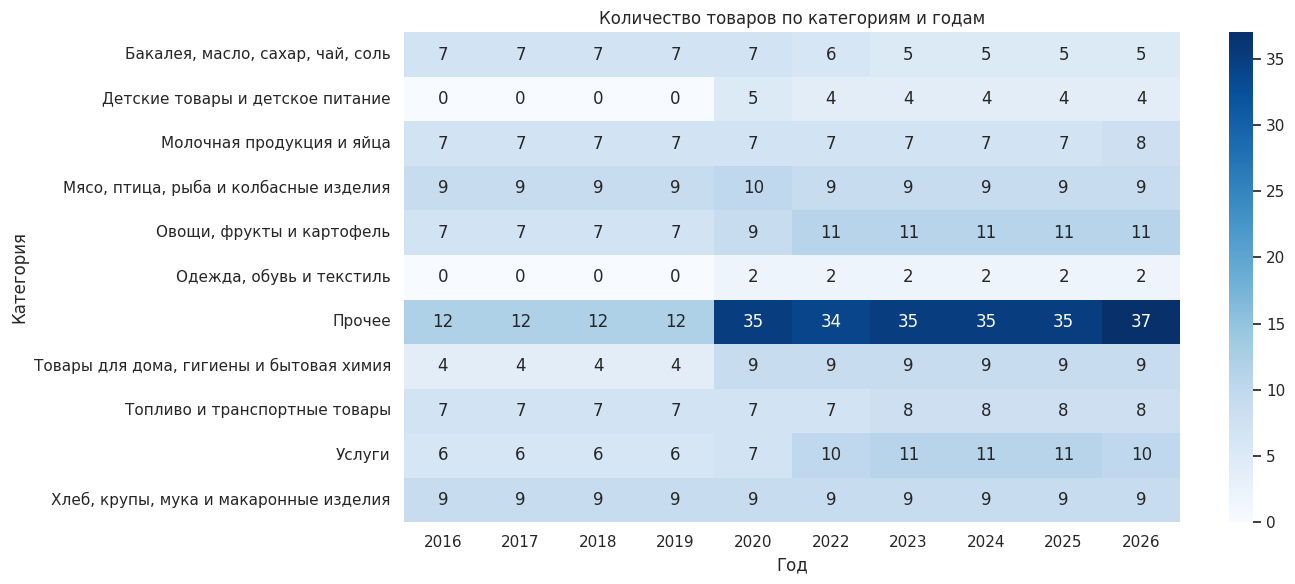

In [89]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    coverage_pivot,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Количество товаров по категориям и годам")
plt.xlabel("Год")
plt.ylabel("Категория")

plt.tight_layout()
plt.show()

In [90]:
OUT_DIR = Path("/content/drive/MyDrive/rostat/processed")

prices_long = pd.read_csv(
    OUT_DIR / "weekly_prices_long.csv",
    parse_dates=["date"]
)

products = pd.read_csv(
    OUT_DIR / "product_dictionary.csv"
)

product_groups = pd.read_csv(
    OUT_DIR / "product_groups.csv"
)

duplicates_report = pd.read_csv(
    OUT_DIR / "duplicates_report.csv"
)

prices_long["year"] = prices_long["date"].dt.year

In [91]:
years_to_use = [2016, 2017, 2018, 2019, 2020, 2022, 2023, 2024, 2025]

# Минимальное количество недельных наблюдений в году,
# чтобы считать, что товар реально присутствует в этом году.
min_dates_per_year = 30

In [92]:
prices_with_products = prices_long.merge(
    products[
        [
            "product_code",
            "product_key",
            "product_name",
            "unit",
            "product_group_code",
            "product_group_name"
        ]
    ],
    on="product_code",
    how="left"
)

prices_with_products = prices_with_products[
    prices_with_products["year"].isin(years_to_use)
].copy()

In [93]:
product_year_presence = (
    prices_with_products
    .groupby(
        [
            "product_group_code",
            "product_group_name",
            "product_code",
            "product_name",
            "year"
        ],
        as_index=False
    )
    .agg(
        n_dates=("date", "nunique"),
        n_rows=("price", "size")
    )
)

product_year_presence["is_present"] = (
    product_year_presence["n_dates"] >= min_dates_per_year
)

In [94]:
presence_pivot = (
    product_year_presence
    .pivot_table(
        index=[
            "product_group_code",
            "product_group_name",
            "product_code",
            "product_name"
        ],
        columns="year",
        values="is_present",
        aggfunc="max",
        fill_value=False
    )
)

# На всякий случай добавляем отсутствующие годы как False
for year in years_to_use:
    if year not in presence_pivot.columns:
        presence_pivot[year] = False

presence_pivot = presence_pivot[years_to_use]

common_products = (
    presence_pivot
    .reset_index()
)

common_products["present_all_years"] = common_products[years_to_use].all(axis=1)

common_products = common_products[
    common_products["present_all_years"]
].copy()

common_product_codes = common_products["product_code"].unique()

print("Количество товаров, присутствующих во всех выбранных годах:", len(common_product_codes))

display(
    common_products[
        [
            "product_group_code",
            "product_group_name",
            "product_code",
            "product_name"
        ]
    ].head(20)
)

Количество товаров, присутствующих во всех выбранных годах: 51


year,product_group_code,product_group_name,product_code,product_name
0,G01,"Хлеб, крупы, мука и макаронные изделия",P0017,Вермишель
1,G01,"Хлеб, крупы, мука и макаронные изделия",P0049,Крупа гречневая-ядрица
2,G01,"Хлеб, крупы, мука и макаронные изделия",P0059,Макаронные изделия из пшеничной муки высшего с...
3,G01,"Хлеб, крупы, мука и макаронные изделия",P0072,Мука пшеничная
4,G01,"Хлеб, крупы, мука и макаронные изделия",P0088,Печенье
5,G01,"Хлеб, крупы, мука и макаронные изделия",P0116,Пшено
6,G01,"Хлеб, крупы, мука и макаронные изделия",P0122,Рис шлифованный
9,G01,"Хлеб, крупы, мука и макаронные изделия",P0152,Хлеб из ржаной муки и из смеси муки ржаной и п...
10,G02,Молочная продукция и яйца,P0063,Масло сливочное
11,G02,Молочная продукция и яйца,P0068,"Молоко питьевое цельное пастеризованное 2,5-3,..."


In [95]:
common_category_counts = (
    common_products
    .groupby(["product_group_code", "product_group_name"], as_index=False)
    .agg(products_count=("product_code", "nunique"))
    .sort_values("product_group_code")
)

display(common_category_counts)

,product_group_code,product_group_name,products_count
0,G01,"Хлеб, крупы, мука и макаронные изделия",8
1,G02,Молочная продукция и яйца,4
2,G03,"Мясо, птица, рыба и колбасные изделия",8
3,G04,"Овощи, фрукты и картофель",7
4,G05,"Бакалея, масло, сахар, чай, соль",4
5,G07,"Товары для дома, гигиены и бытовая химия",4
6,G10,Топливо и транспортные товары,5
7,G11,Услуги,5
8,G99,Прочее,6


In [96]:
prices_long_filtered = prices_long[
    prices_long["year"].isin(years_to_use)
    & prices_long["product_code"].isin(common_product_codes)
].copy()

products_filtered = products[
    products["product_code"].isin(common_product_codes)
].copy()

remaining_group_codes = products_filtered["product_group_code"].unique()

product_groups_filtered = product_groups[
    product_groups["product_group_code"].isin(remaining_group_codes)
].copy()

duplicates_report_filtered = duplicates_report[
    duplicates_report["product_key"].isin(products_filtered["product_key"])
].copy()

In [97]:
prices_wide_filtered = (
    prices_long_filtered
    .pivot_table(
        index="date",
        columns="product_code",
        values="price",
        aggfunc="mean"
    )
    .reset_index()
)

prices_wide_filtered.columns.name = None

In [98]:
check_equal_products = (
    prices_long_filtered
    .merge(
        products_filtered[
            [
                "product_code",
                "product_group_code",
                "product_group_name"
            ]
        ],
        on="product_code",
        how="left"
    )
    .assign(year=lambda df: df["date"].dt.year)
    .groupby(["product_group_name", "year"])
    .agg(
        n_products=("product_code", "nunique"),
        n_dates=("date", "nunique"),
        n_rows=("price", "size")
    )
    .reset_index()
)

check_pivot = (
    check_equal_products
    .pivot_table(
        index="product_group_name",
        columns="year",
        values="n_products",
        aggfunc="sum"
    )
    .fillna(0)
    .astype(int)
)

display(check_pivot)

year,2016,2017,2018,2019,2020,2022,2023,2024,2025
product_group_name,,,,,,,,,
"Бакалея, масло, сахар, чай, соль",4,4,4,4,4,4,4,4,4
Молочная продукция и яйца,4,4,4,4,4,4,4,4,4
"Мясо, птица, рыба и колбасные изделия",8,8,8,8,8,8,8,8,8
"Овощи, фрукты и картофель",7,7,7,7,7,7,7,7,7
Прочее,6,6,6,6,6,6,6,6,6
"Товары для дома, гигиены и бытовая химия",4,4,4,4,4,4,4,4,4
Топливо и транспортные товары,5,5,5,5,5,5,5,5,5
Услуги,5,5,5,5,5,5,5,5,5
"Хлеб, крупы, мука и макаронные изделия",8,8,8,8,8,8,8,8,8


In [99]:
prices_long_filtered.to_csv(
    OUT_DIR / "weekly_prices_long.csv",
    index=False,
    encoding="utf-8-sig"
)

prices_wide_filtered.to_csv(
    OUT_DIR / "weekly_prices_wide.csv",
    index=False,
    encoding="utf-8-sig"
)

products_filtered.to_csv(
    OUT_DIR / "product_dictionary.csv",
    index=False,
    encoding="utf-8-sig"
)

product_groups_filtered.to_csv(
    OUT_DIR / "product_groups.csv",
    index=False,
    encoding="utf-8-sig"
)

duplicates_report_filtered.to_csv(
    OUT_DIR / "duplicates_report.csv",
    index=False,
    encoding="utf-8-sig"
)

print("CSV-файлы перезаписаны в:", OUT_DIR)

CSV-файлы перезаписаны в: /content/drive/MyDrive/rostat/processed


In [100]:
print("Итог после фильтрации")

print("\nweekly_prices_long.csv:")
print(prices_long_filtered.shape)
print("Период:", prices_long_filtered["date"].min(), "—", prices_long_filtered["date"].max())
print("Количество товаров:", prices_long_filtered["product_code"].nunique())
print("Количество дат:", prices_long_filtered["date"].nunique())

print("\nРаспределение товаров по категориям:")
display(
    products_filtered
    .groupby(["product_group_code", "product_group_name"], as_index=False)
    .agg(products_count=("product_code", "nunique"))
    .sort_values("product_group_code")
)

print("\nКоличество товаров по категориям и годам:")
display(check_pivot)

Итог после фильтрации

weekly_prices_long.csv:
(23193, 6)
Период: 2016-01-11 00:00:00 — 2025-12-22 00:00:00
Количество товаров: 51
Количество дат: 455

Распределение товаров по категориям:


,product_group_code,product_group_name,products_count
0,G01,"Хлеб, крупы, мука и макаронные изделия",8
1,G02,Молочная продукция и яйца,4
2,G03,"Мясо, птица, рыба и колбасные изделия",8
3,G04,"Овощи, фрукты и картофель",7
4,G05,"Бакалея, масло, сахар, чай, соль",4
5,G07,"Товары для дома, гигиены и бытовая химия",4
6,G10,Топливо и транспортные товары,5
7,G11,Услуги,5
8,G99,Прочее,6



Количество товаров по категориям и годам:


year,2016,2017,2018,2019,2020,2022,2023,2024,2025
product_group_name,,,,,,,,,
"Бакалея, масло, сахар, чай, соль",4,4,4,4,4,4,4,4,4
Молочная продукция и яйца,4,4,4,4,4,4,4,4,4
"Мясо, птица, рыба и колбасные изделия",8,8,8,8,8,8,8,8,8
"Овощи, фрукты и картофель",7,7,7,7,7,7,7,7,7
Прочее,6,6,6,6,6,6,6,6,6
"Товары для дома, гигиены и бытовая химия",4,4,4,4,4,4,4,4,4
Топливо и транспортные товары,5,5,5,5,5,5,5,5,5
Услуги,5,5,5,5,5,5,5,5,5
"Хлеб, крупы, мука и макаронные изделия",8,8,8,8,8,8,8,8,8


In [101]:
OUT_DIR = Path("/content/drive/MyDrive/rostat/processed")

prices_long = pd.read_csv(
    OUT_DIR / "weekly_prices_long.csv",
    parse_dates=["date"]
)

products = pd.read_csv(
    OUT_DIR / "product_dictionary.csv"
)

prices_plot = prices_long.merge(
    products[
        [
            "product_code",
            "product_name",
            "product_group_code",
            "product_group_name"
        ]
    ],
    on="product_code",
    how="left"
)

prices_plot["year"] = prices_plot["date"].dt.year

prices_plot.head()

,date,year,product_code,price,source_file,source_sheet,product_name,product_group_code,product_group_name
0,2016-01-11,2016,P0005,341.28,[2016-2020]_price_spred.xlsx,Данные,Баранина (кроме бескостного мяса),G03,"Мясо, птица, рыба и колбасные изделия"
1,2016-01-11,2016,P0006,34.89,[2016-2020]_price_spred.xlsx,Данные,Бензин автомобильный,G10,Топливо и транспортные товары
2,2016-01-11,2016,P0008,33.91,[2016-2020]_price_spred.xlsx,Данные,Бензин автомобильный марки АИ-92,G10,Топливо и транспортные товары
3,2016-01-11,2016,P0009,36.80,[2016-2020]_price_spred.xlsx,Данные,Бензин автомобильный марки АИ-95,G10,Топливо и транспортные товары
4,2016-01-11,2016,P0017,64.09,[2016-2020]_price_spred.xlsx,Данные,Вермишель,G01,"Хлеб, крупы, мука и макаронные изделия"


In [102]:
category_mean_ts = (
    prices_plot
    .groupby(["date", "product_group_name"], as_index=False)
    .agg(mean_price=("price", "mean"))
    .sort_values(["product_group_name", "date"])
)

category_mean_ts.head()

,date,product_group_name,mean_price
0,2016-01-11,"Бакалея, масло, сахар, чай, соль",216.310
9,2016-01-18,"Бакалея, масло, сахар, чай, соль",216.920
18,2016-01-25,"Бакалея, масло, сахар, чай, соль",217.695
27,2016-02-01,"Бакалея, масло, сахар, чай, соль",216.435
36,2016-02-08,"Бакалея, масло, сахар, чай, соль",217.310


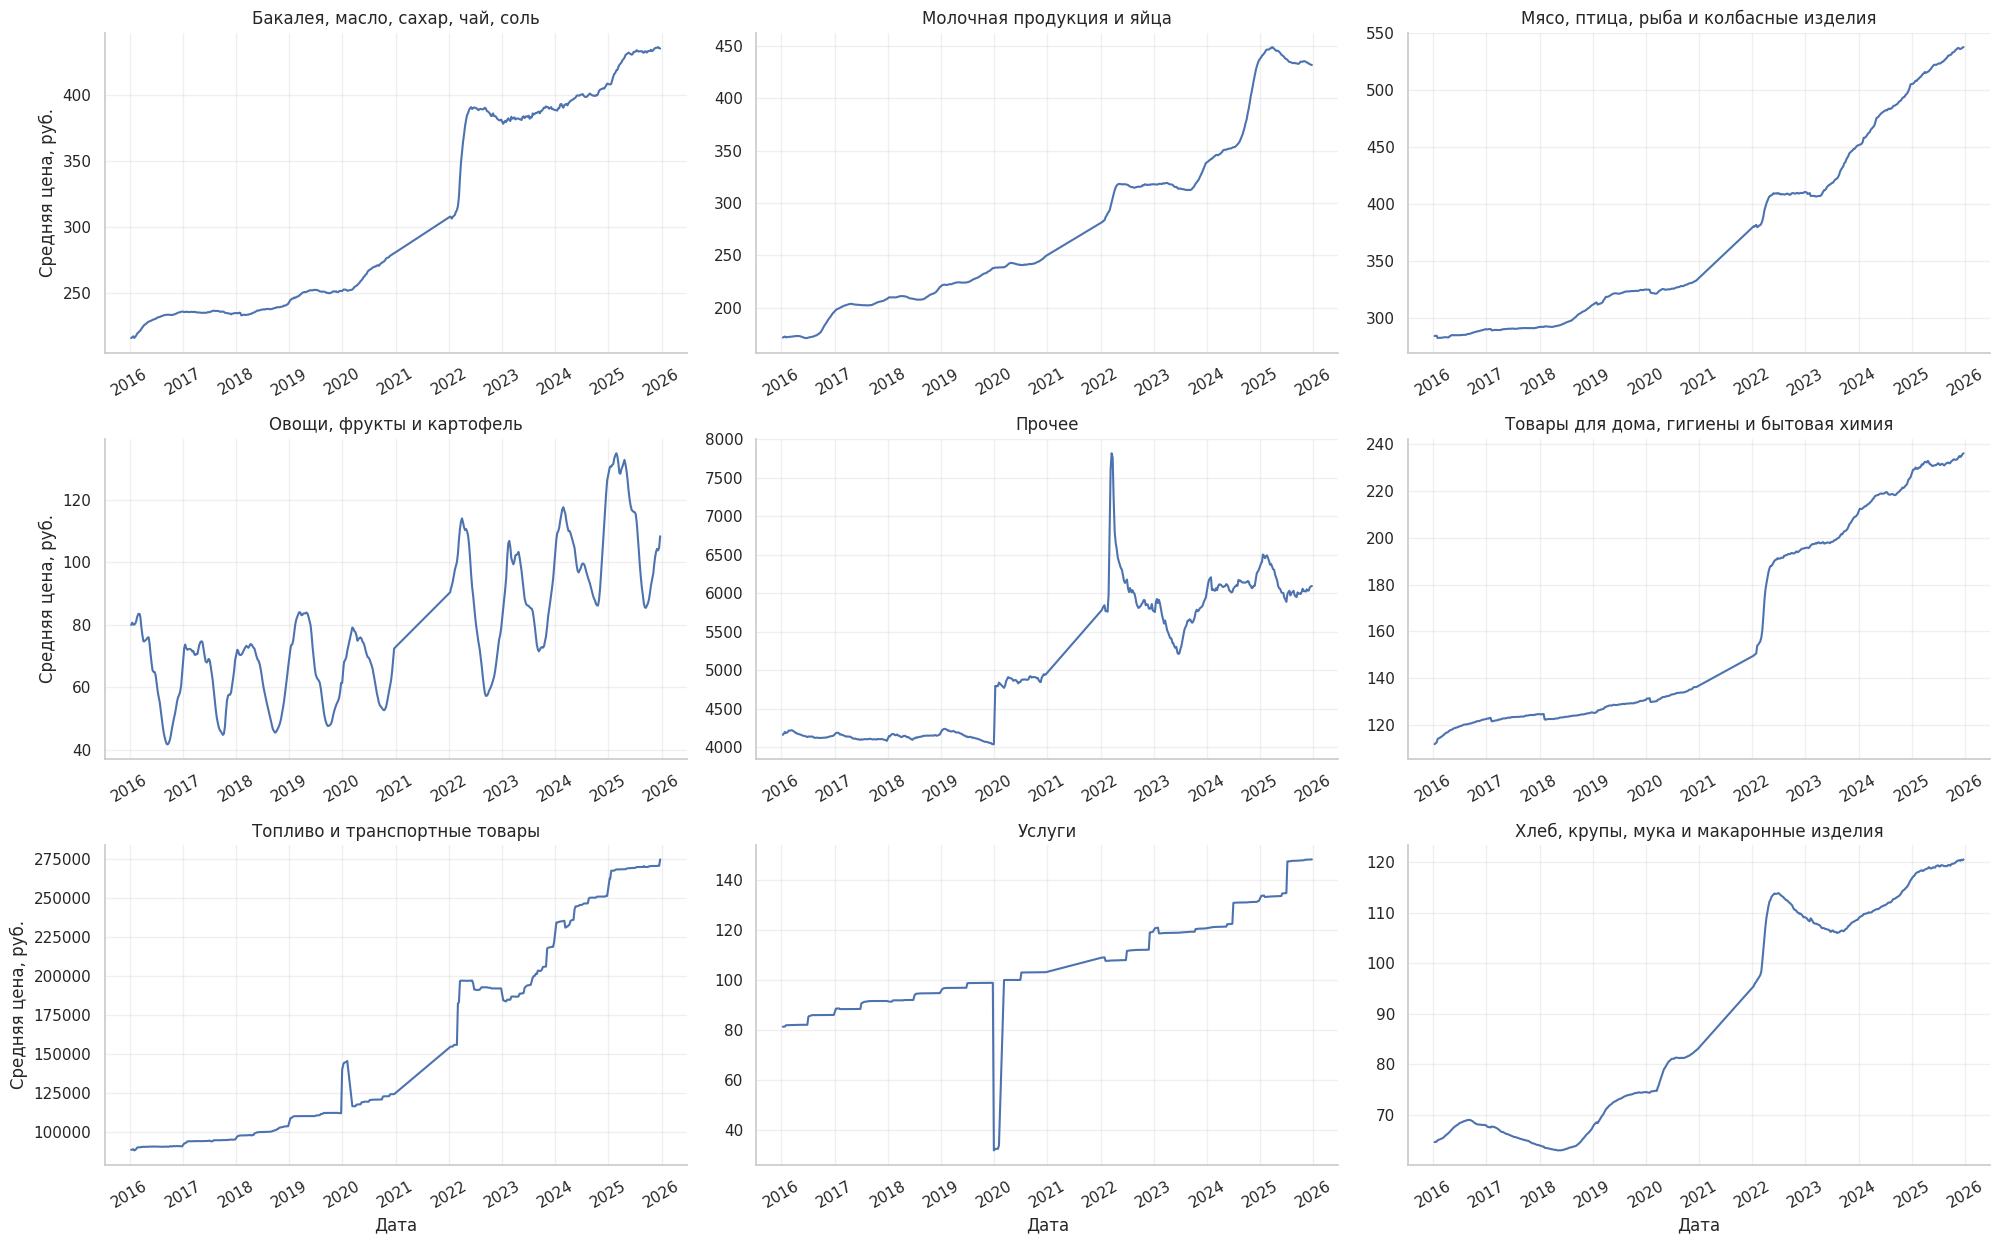

In [103]:
sns.set_theme(style="whitegrid")

g = sns.FacetGrid(
    category_mean_ts,
    col="product_group_name",
    col_wrap=3,
    height=4.2,
    aspect=1.6,
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="date",
    y="mean_price"
)

g.set_axis_labels("Дата", "Средняя цена, руб.")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.tick_params(axis="x", labelrotation=30)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [104]:
OUT_DIR = Path("/content/drive/MyDrive/rostat/processed")

products = pd.read_csv(
    OUT_DIR / "product_dictionary.csv"
)

products.head()

,product_code,product_key,product_name,unit,product_group_code,product_group_name,product_raw
0,P0005,баранина_кроме_бескостного_мяса__кг,Баранина (кроме бескостного мяса),кг,G03,"Мясо, птица, рыба и колбасные изделия","Баранина (кроме бескостного мяса), кг"
1,P0006,бензин_автомобильный,Бензин автомобильный,NaN,G10,Топливо и транспортные товары,Бензин автомобильный
2,P0008,бензин_автомобильный_марки_аи_92__л,Бензин автомобильный марки АИ-92,л,G10,Топливо и транспортные товары,"Бензин автомобильный марки АИ-92, л"
3,P0009,бензин_автомобильный_марки_аи_95__л,Бензин автомобильный марки АИ-95,л,G10,Топливо и транспортные товары,"Бензин автомобильный марки АИ-95, л"
4,P0017,вермишель__кг,Вермишель,кг,G01,"Хлеб, крупы, мука и макаронные изделия","Вермишель, кг"


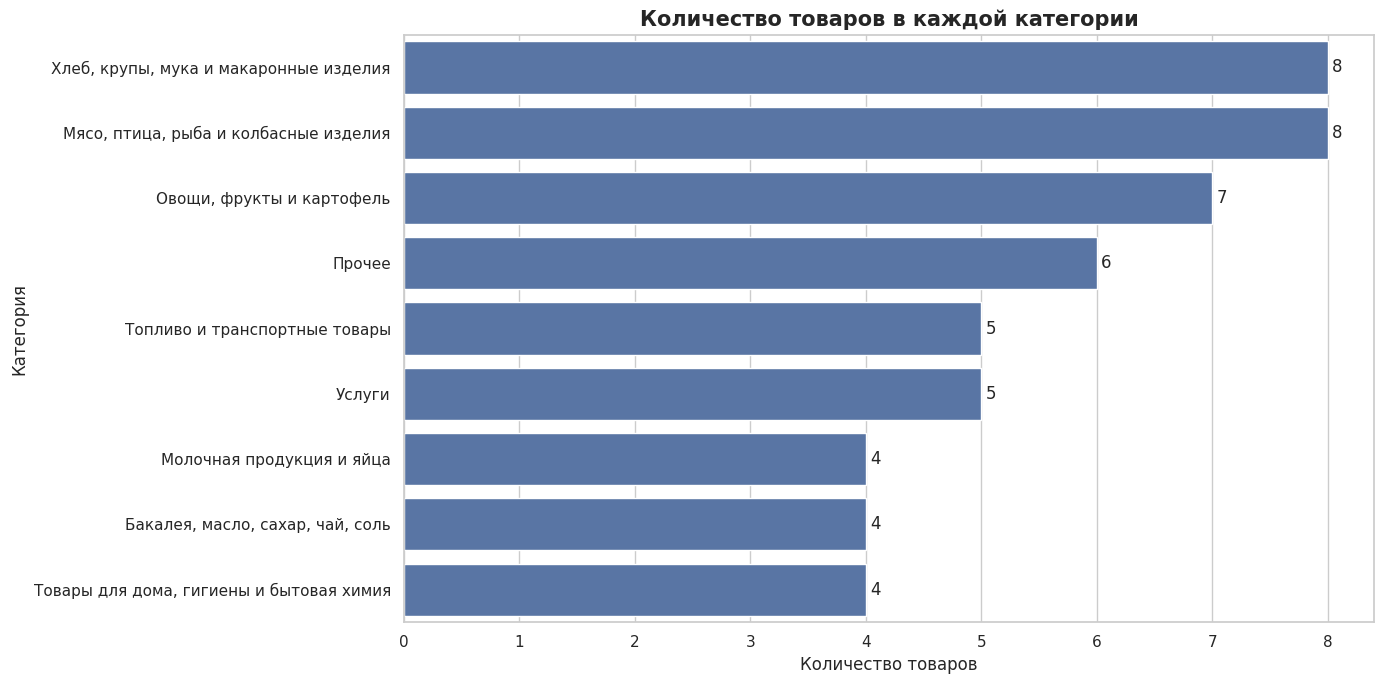

In [105]:
category_counts = (
    products
    .groupby(["product_group_code", "product_group_name"], as_index=False)
    .agg(products_count=("product_code", "nunique"))
    .sort_values("products_count", ascending=False)
)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=category_counts,
    x="products_count",
    y="product_group_name"
)

plt.title("Количество товаров в каждой категории", fontsize=15, fontweight="bold")
plt.xlabel("Количество товаров")
plt.ylabel("Категория")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

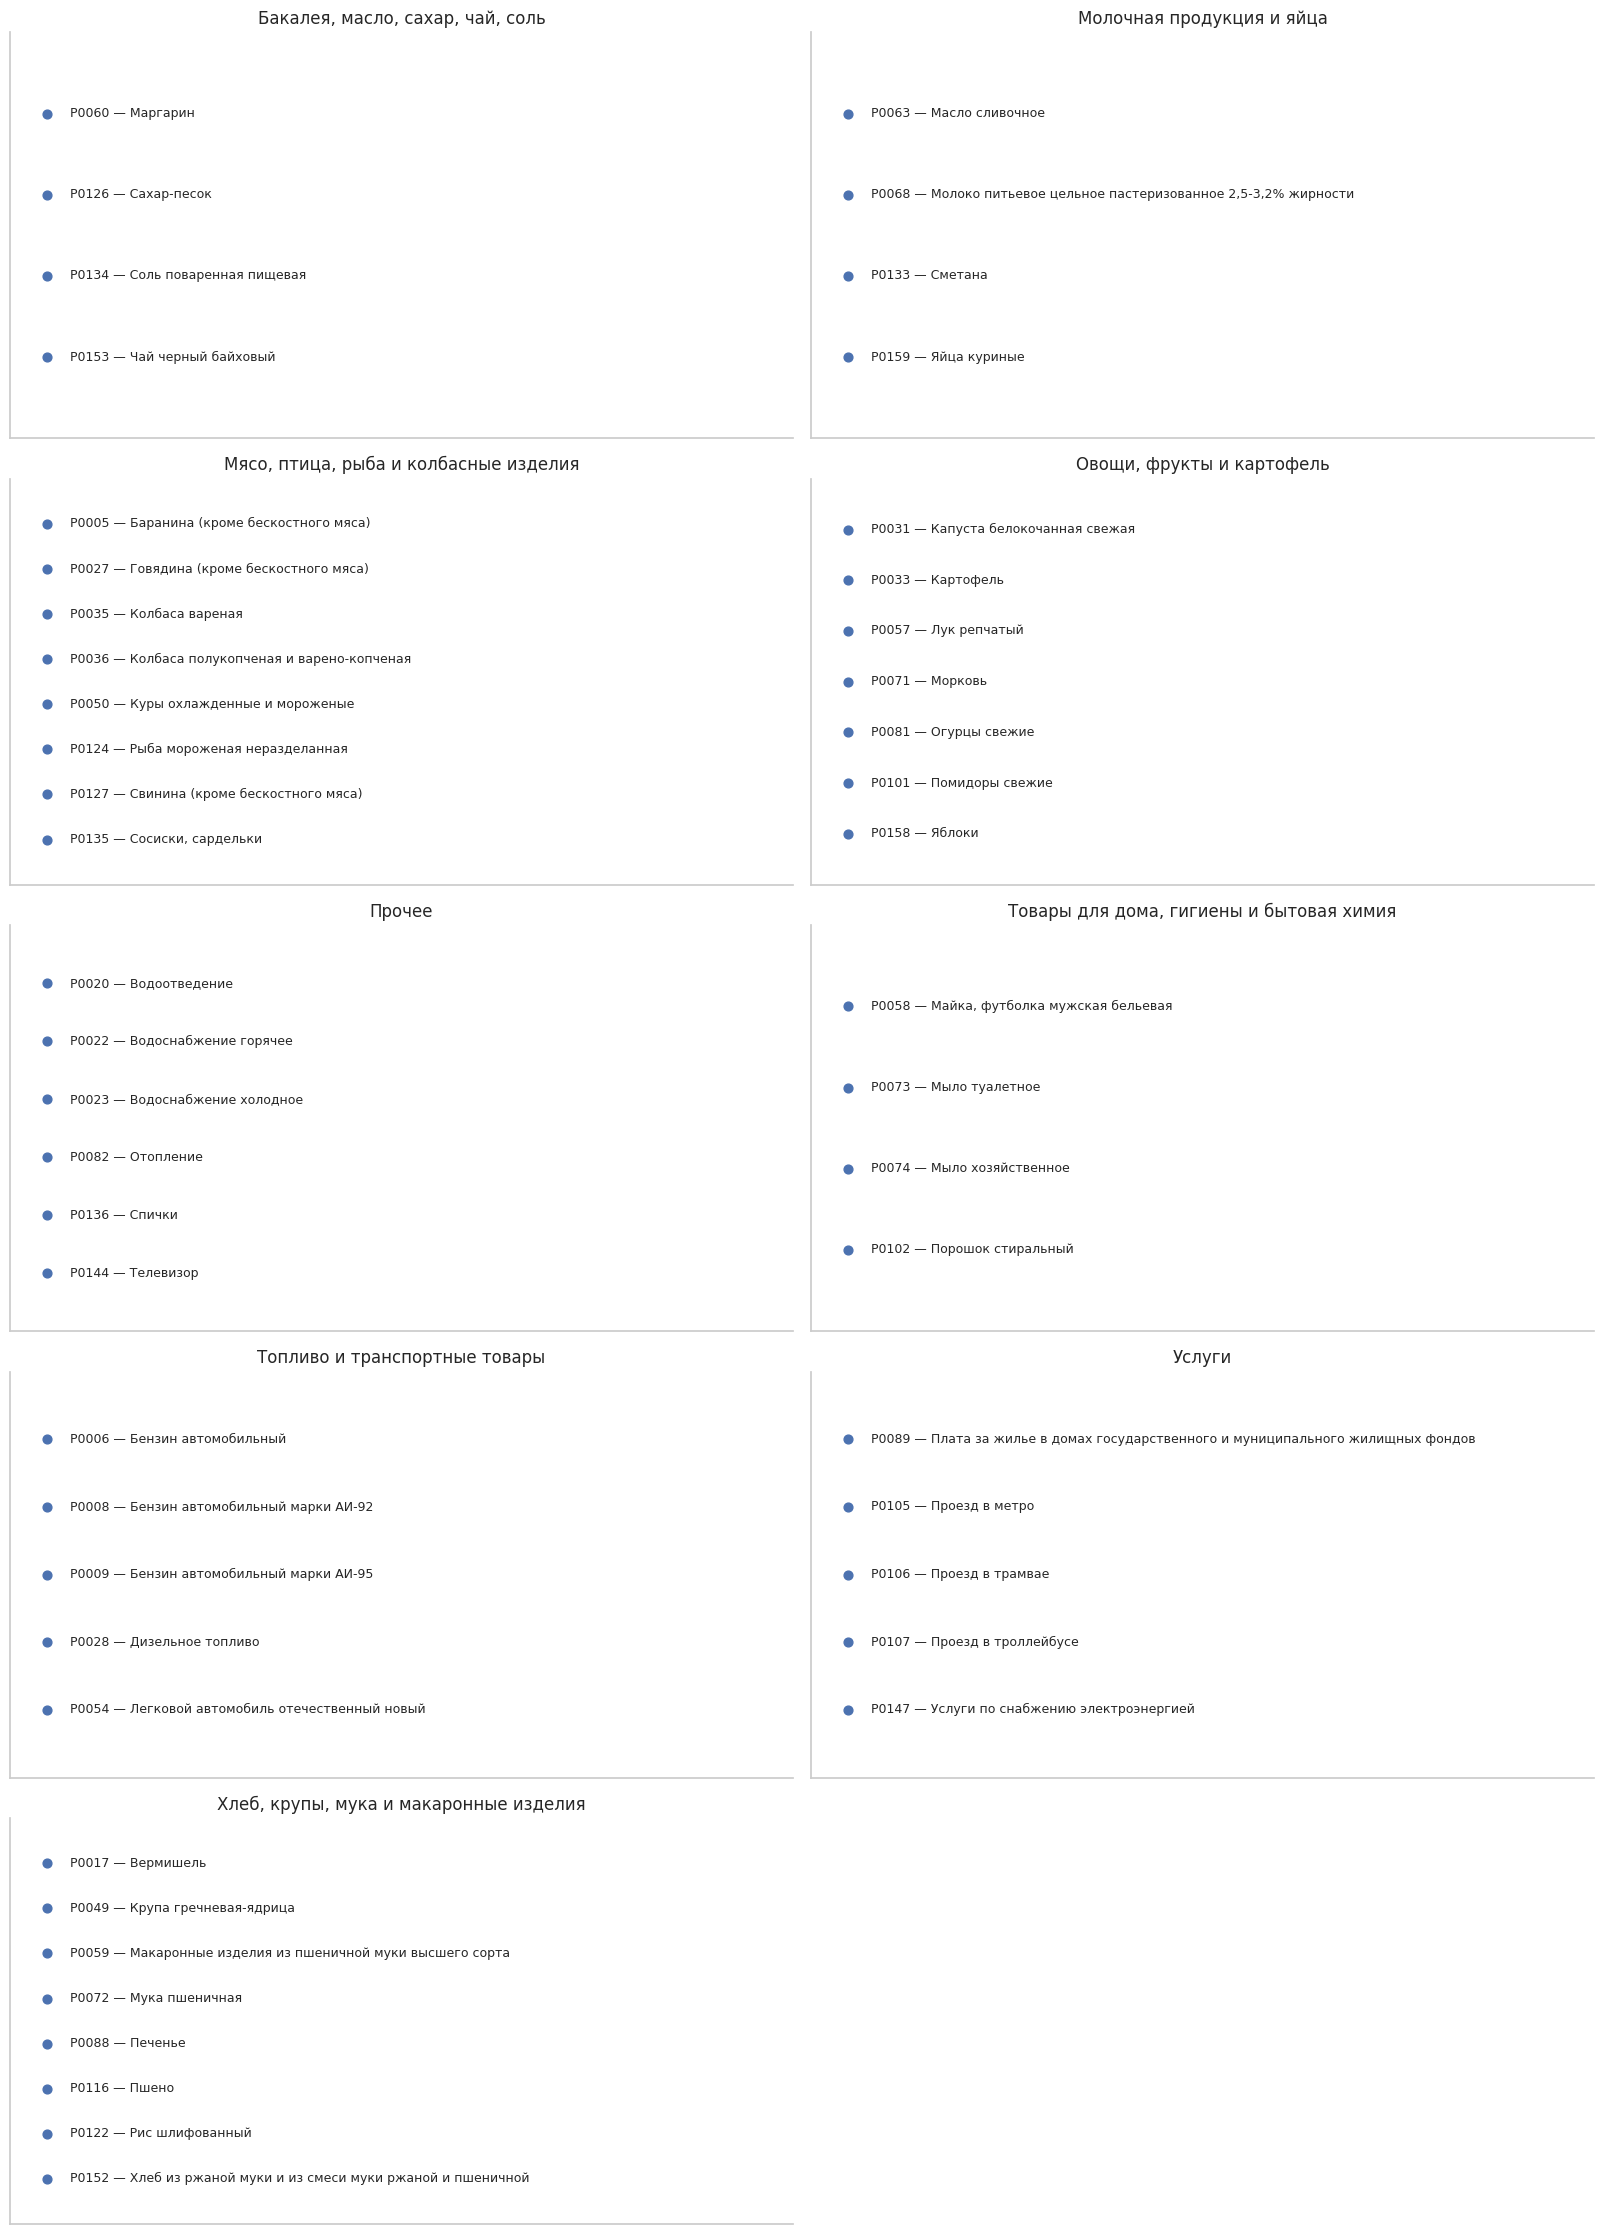

In [106]:
products_for_plot = products.copy()

products_for_plot = products_for_plot.sort_values(
    ["product_group_name", "product_name"]
)

g = sns.FacetGrid(
    products_for_plot,
    col="product_group_name",
    col_wrap=2,
    height=4.5,
    aspect=1.8,
    sharex=False,
    sharey=False
)

def draw_product_list(data, **kwargs):
    ax = plt.gca()
    data = data.sort_values("product_name").reset_index(drop=True)
    
    ax.scatter(
        [0] * len(data),
        range(len(data)),
        s=40
    )
    
    for i, row in data.iterrows():
        ax.text(
            0.03,
            i,
            f"{row['product_code']} — {row['product_name']}",
            va="center",
            fontsize=9
        )
    
    ax.set_xlim(-0.05, 1)
    ax.set_ylim(-1, len(data))
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

g.map_dataframe(draw_product_list)

g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.grid(False)

plt.tight_layout()
plt.show()

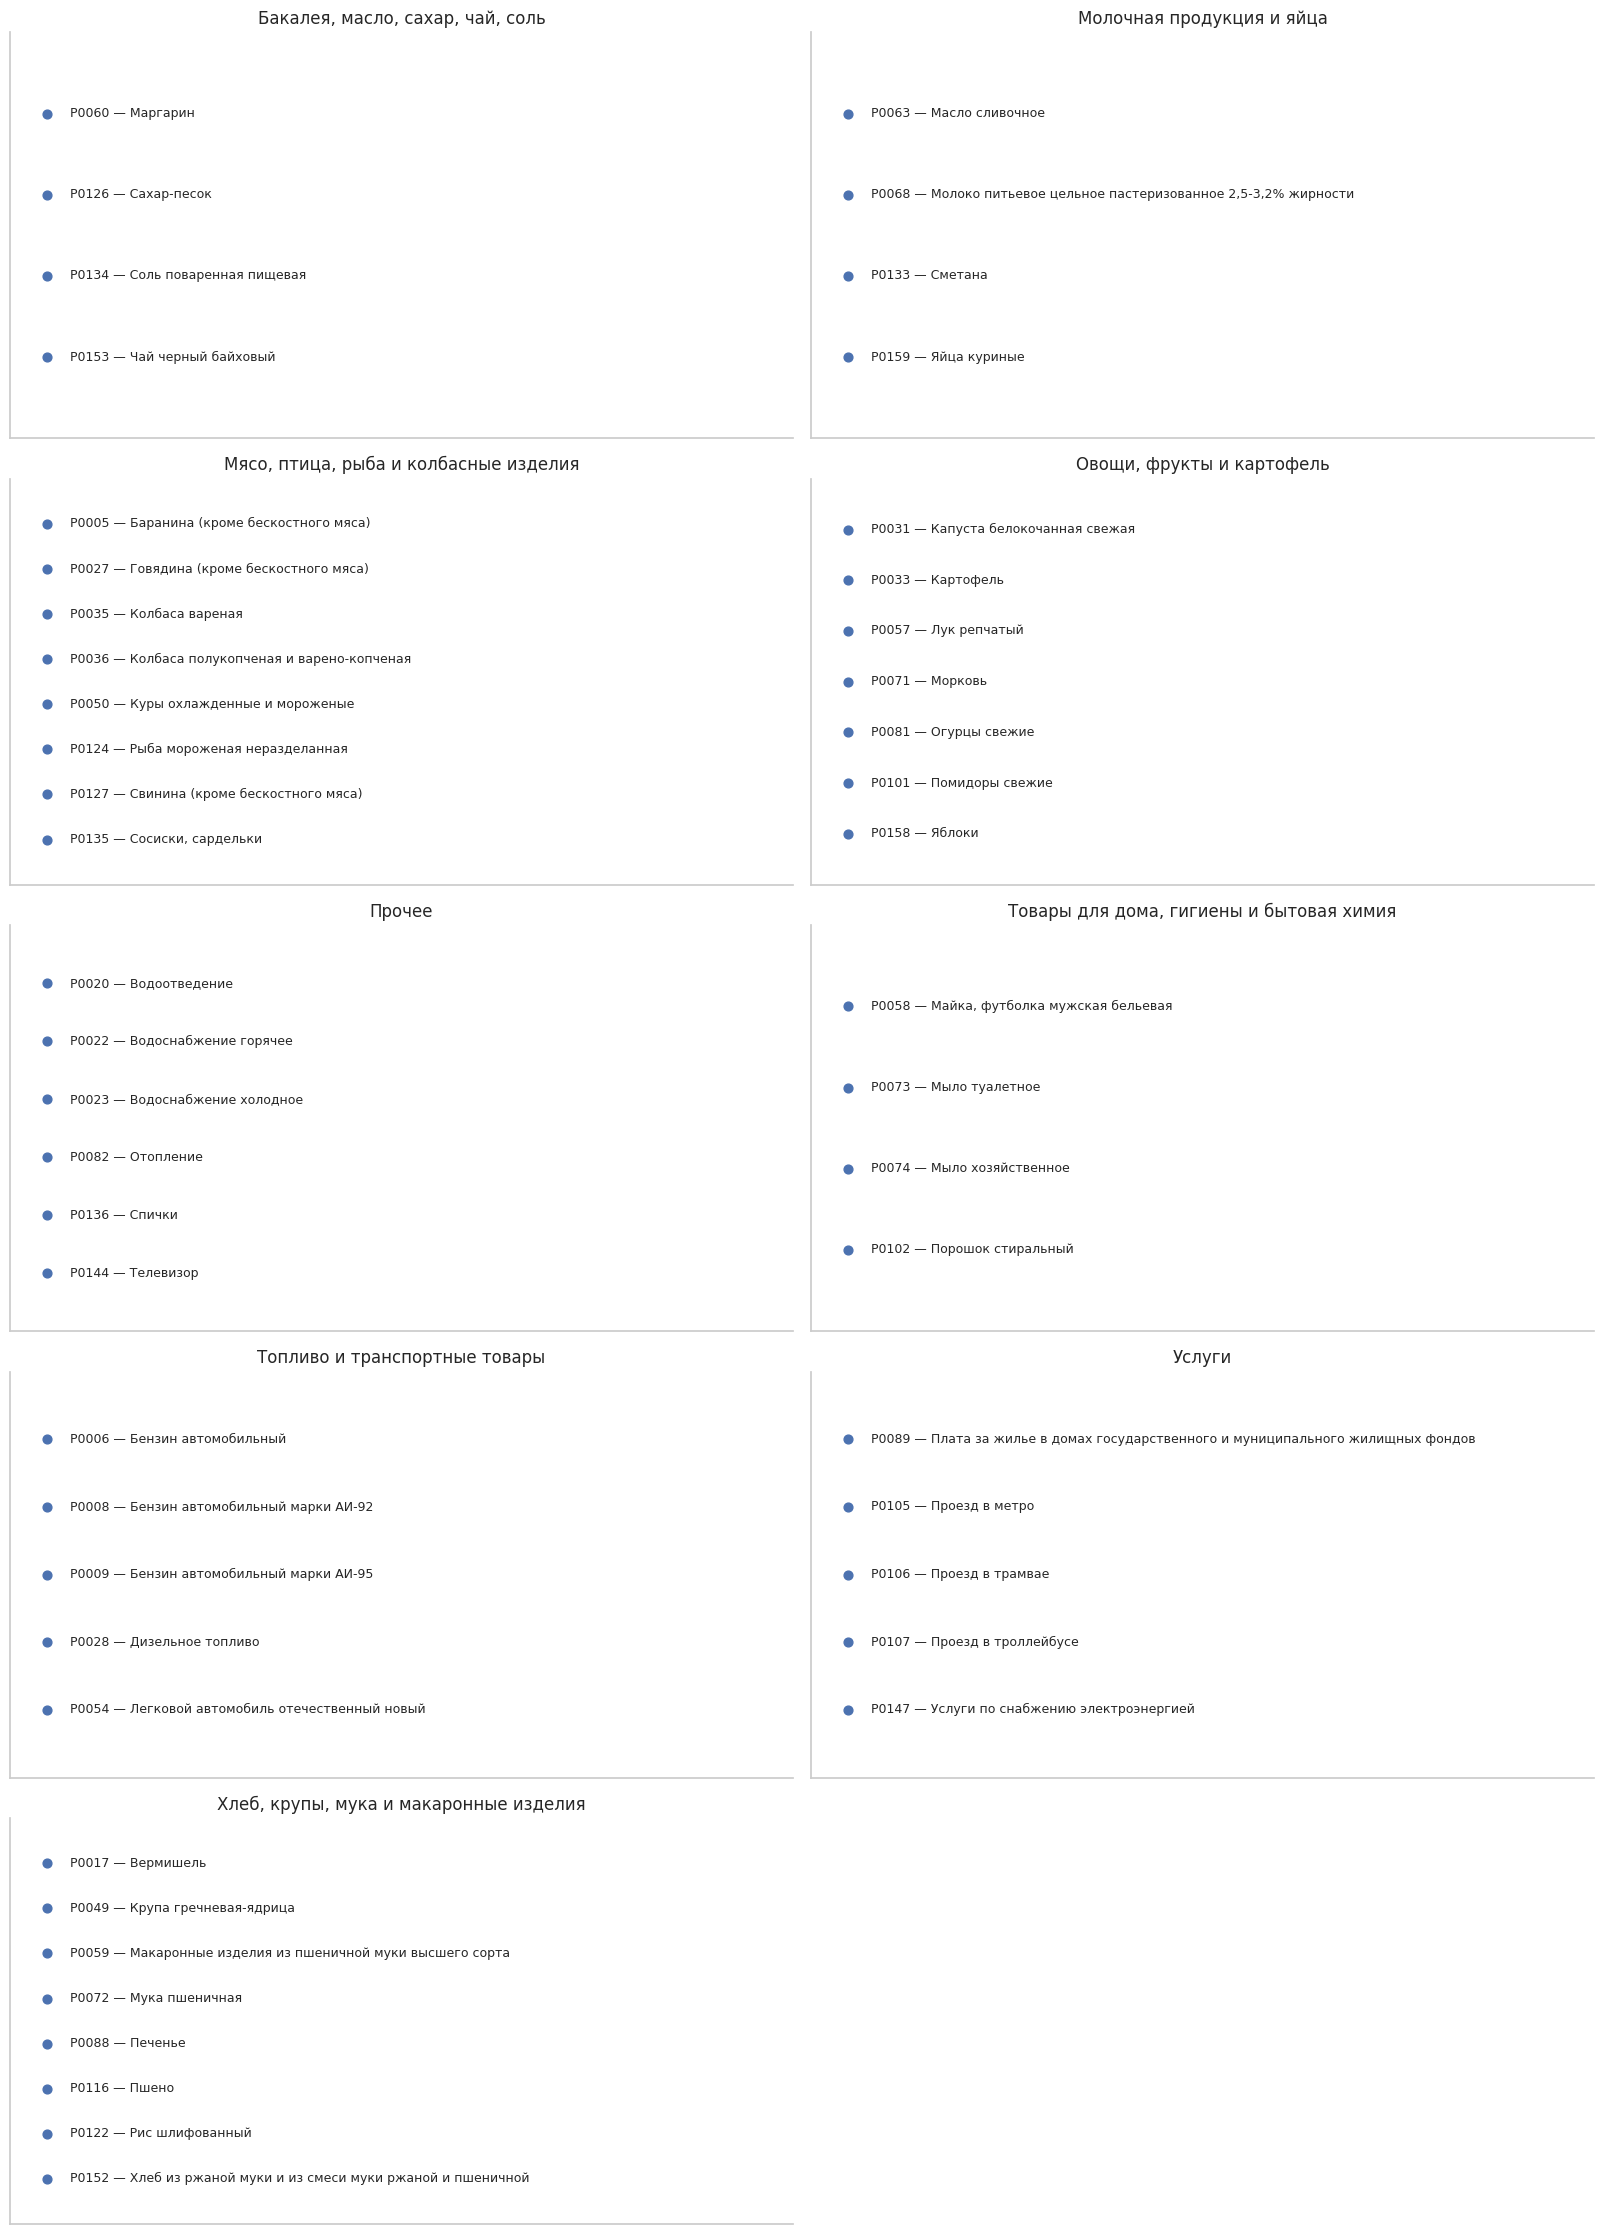

In [107]:
products_for_plot = products.copy()

products_for_plot = products_for_plot.sort_values(
    ["product_group_name", "product_name"]
)

g = sns.FacetGrid(
    products_for_plot,
    col="product_group_name",
    col_wrap=2,
    height=4.5,
    aspect=1.8,
    sharex=False,
    sharey=False
)

def draw_product_list(data, **kwargs):
    ax = plt.gca()
    data = data.sort_values("product_name").reset_index(drop=True)
    
    ax.scatter(
        [0] * len(data),
        range(len(data)),
        s=40
    )
    
    for i, row in data.iterrows():
        ax.text(
            0.03,
            i,
            f"{row['product_code']} — {row['product_name']}",
            va="center",
            fontsize=9
        )
    
    ax.set_xlim(-0.05, 1)
    ax.set_ylim(-1, len(data))
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

g.map_dataframe(draw_product_list)

g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.grid(False)

plt.tight_layout()
plt.show()

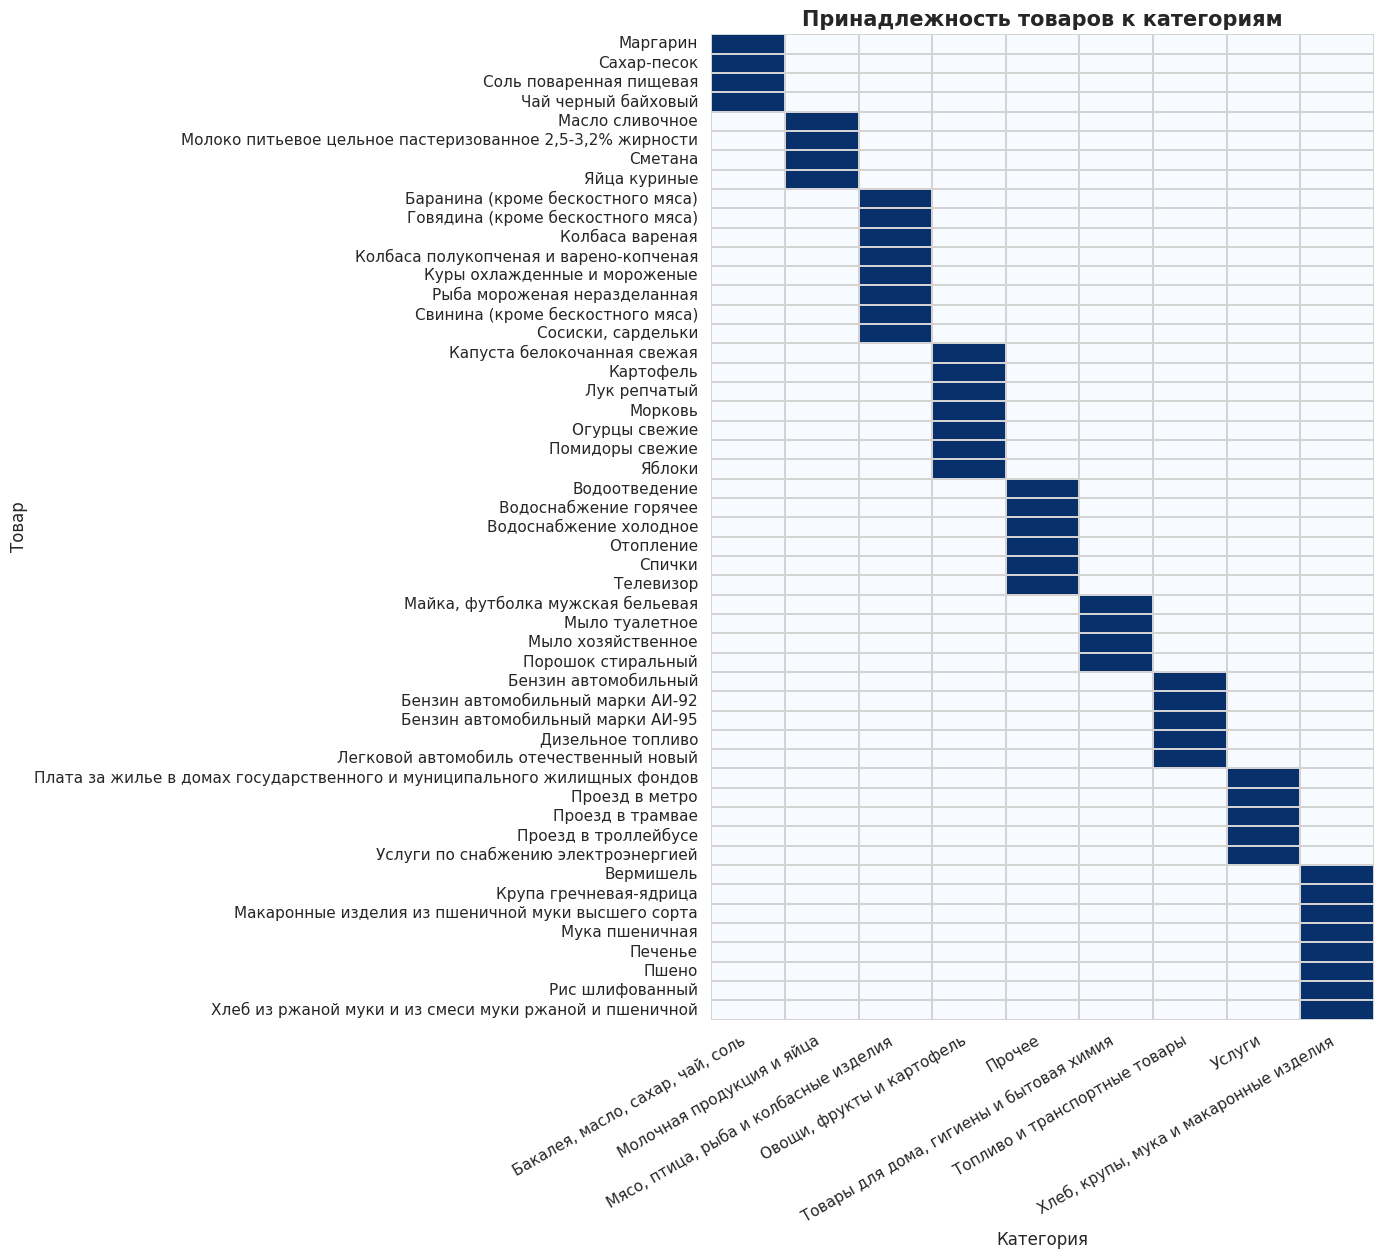

In [108]:
product_category_matrix = (
    products
    .assign(value=1)
    .pivot_table(
        index="product_name",
        columns="product_group_name",
        values="value",
        fill_value=0
    )
)

# Чтобы график не был слишком огромным, сортируем товары по категории
product_order = (
    products
    .sort_values(["product_group_name", "product_name"])
    ["product_name"]
    .tolist()
)

product_category_matrix = product_category_matrix.loc[product_order]

plt.figure(figsize=(14, max(8, len(product_category_matrix) * 0.25)))

sns.heatmap(
    product_category_matrix,
    cmap="Blues",
    cbar=False,
    linewidths=0.2,
    linecolor="lightgray"
)

plt.title("Принадлежность товаров к категориям", fontsize=15, fontweight="bold")
plt.xlabel("Категория")
plt.ylabel("Товар")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

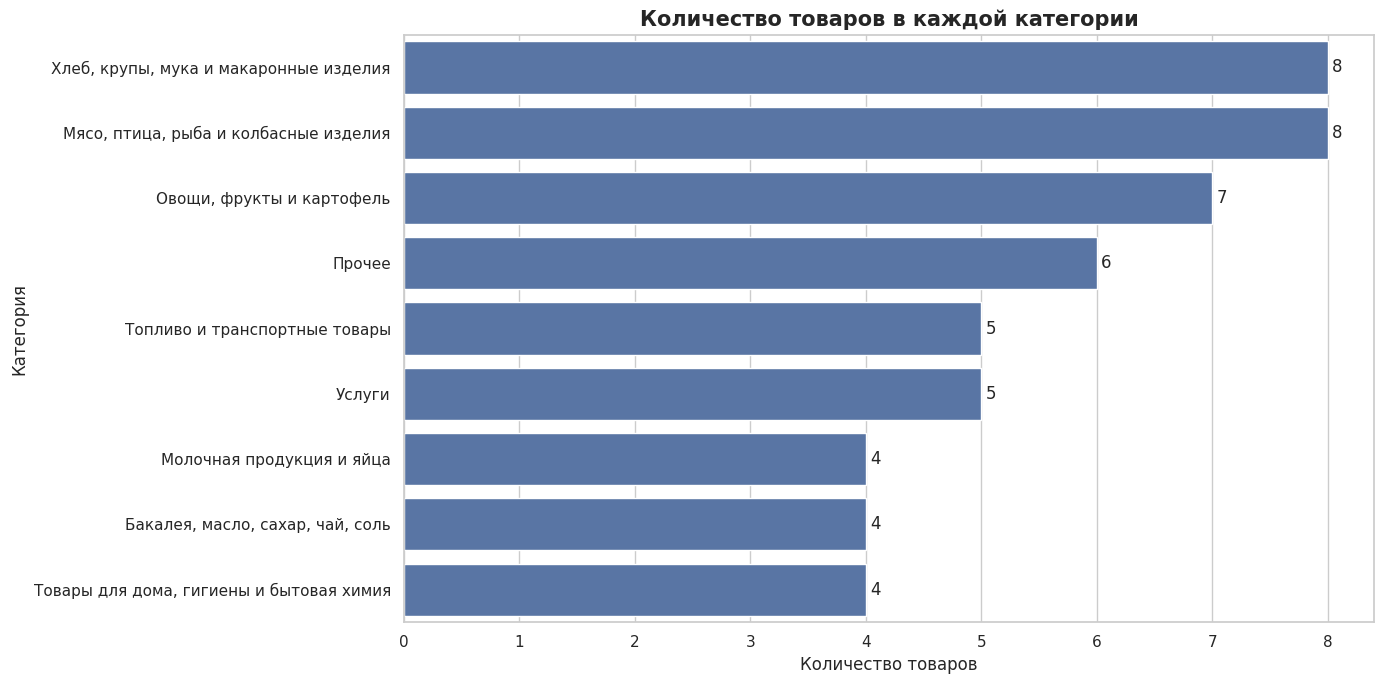

In [109]:
category_counts = (
    products
    .groupby(["product_group_code", "product_group_name"], as_index=False)
    .agg(products_count=("product_code", "nunique"))
    .sort_values("products_count", ascending=False)
)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=category_counts,
    x="products_count",
    y="product_group_name"
)

plt.title("Количество товаров в каждой категории", fontsize=15, fontweight="bold")
plt.xlabel("Количество товаров")
plt.ylabel("Категория")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

In [110]:
category_product_list = (
    products
    .sort_values(["product_group_name", "product_name"])
    .groupby("product_group_name", as_index=False)
    .agg(
        products_count=("product_code", "nunique"),
        products_list=("product_name", lambda x: "; ".join(x))
    )
)

display(category_product_list)

,product_group_name,products_count,products_list
0,"Бакалея, масло, сахар, чай, соль",4,Маргарин; Сахар-песок; Соль поваренная пищевая...
1,Молочная продукция и яйца,4,Масло сливочное; Молоко питьевое цельное пасте...
2,"Мясо, птица, рыба и колбасные изделия",8,Баранина (кроме бескостного мяса); Говядина (к...
3,"Овощи, фрукты и картофель",7,Капуста белокочанная свежая; Картофель; Лук ре...
4,Прочее,6,Водоотведение; Водоснабжение горячее; Водоснаб...
5,"Товары для дома, гигиены и бытовая химия",4,"Майка, футболка мужская бельевая; Мыло туалетн..."
6,Топливо и транспортные товары,5,Бензин автомобильный; Бензин автомобильный мар...
7,Услуги,5,Плата за жилье в домах государственного и муни...
8,"Хлеб, крупы, мука и макаронные изделия",8,Вермишель; Крупа гречневая-ядрица; Макаронные ...
